# Models - Juan

Pregunta sustantiva
¿qué pasó con los precios?
¿qué pasó con la actividad contractual?
¿hubo heterogeneidad territorial?
¿el régimen posterior parece distinto?

In [1]:
# import for panel regression   
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
# install linearmodels package for panel regression
!pip install linearmodels
from linearmodels.panel import PanelOLS
# import for data visualization
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import datasets


In [3]:
# Load the dataset
df_distritos_eda = pd.read_parquet('data_final/df_distritos_eda.parquet')
df_barrios_eda= pd.read_parquet('data_final/df_barrios_eda.parquet')
df_barrios_hypothesis = pd.read_parquet('data_final/df_barrios_hypothesis.parquet')
city_ts_distritos = pd.read_parquet('data_final/city_ts_distritos.parquet')



In [4]:
df_distritos_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   district_code              1030 non-null   int64         
 1   district                   1030 non-null   category      
 2   year                       1030 non-null   int64         
 3   quarter                    1030 non-null   int64         
 4   num_contracts              1030 non-null   Int64         
 5   avg_rent                   1030 non-null   float64       
 6   avg_rent_m2                1030 non-null   float64       
 7   avg_surface                1030 non-null   float64       
 8   date                       1030 non-null   datetime64[ns]
 9   contract_growth_yoy        990 non-null    Float64       
 10  rent_growth_yoy            990 non-null    float64       
 11  rent_m2_growth_yoy         990 non-null    float64       
 12  contra

In [5]:
df_barrios_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3102 entries, 0 to 3101
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   neighborhood_code          3102 non-null   int64         
 1   neighborhood               3102 non-null   category      
 2   year                       3102 non-null   int64         
 3   quarter                    3102 non-null   int64         
 4   num_contracts              3102 non-null   Int64         
 5   avg_rent                   3102 non-null   float64       
 6   avg_rent_m2                3102 non-null   float64       
 7   avg_surface                3102 non-null   float64       
 8   date                       3102 non-null   datetime64[ns]
 9   contract_growth_yoy        2838 non-null   Float64       
 10  rent_growth_yoy            2838 non-null   float64       
 11  rent_m2_growth_yoy         2838 non-null   float64       
 12  contra

In [6]:
freq = (
    df_barrios_eda.groupby('neighborhood')['num_contracts']
    .mean()
    .sort_values(ascending=False)
)

for barrio, valor in freq.items():
    print(f"{barrio}: {valor:.2f}")


la Vila de Gràcia: 562.57
la Nova Esquerra de l'Eixample: 472.45
l'Antiga Esquerra de l'Eixample: 437.62
la Dreta de l'Eixample: 424.28
la Sagrada Família: 401.06
el Raval: 399.96
Sant Gervasi - Galvany: 381.91
Sants: 312.94
Sant Antoni: 301.15
les Corts: 295.47
el Poble Sec - AEI Parc Montjuïc: 280.98
el Camp de l'Arpa del Clot: 276.13
el Putxet i el Farró: 271.68
Sant Pere, Santa Caterina i la Ribera: 268.87
el Camp d'en Grassot i Gràcia Nova: 260.28
Sant Andreu: 255.85
el Fort Pienc: 237.40
el Guinardó: 232.15
el Poblenou: 217.68
Sant Gervasi - la Bonanova: 192.19
el Barri Gòtic: 189.15
Sants - Badal: 162.79
el Baix Guinardó: 162.34
Sarrià: 161.53
el Carmel: 155.21
la Sagrera: 155.13
el Clot: 143.68
la Maternitat i Sant Ramon: 138.28
Horta: 129.98
Porta: 123.11
Vilapicina i la Torre Llobeta: 122.06
Hostafrancs: 120.53
Vallcarca i els Penitents: 118.30
la Prosperitat: 116.19
la Barceloneta: 116.02
Navas: 111.98
la Bordeta: 107.45
Sant Martí de Provençals: 105.36
la Verneda i la Pau: 

C:\Users\jrort\AppData\Local\Temp\ipykernel_59812\1121897363.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_barrios_eda.groupby('neighborhood')['num_contracts']


In [7]:
df_barrios_eda.groupby('neighborhood')['population_total'] \
              .mean() \
              .sort_values(ascending=False) \
              .head(10)


C:\Users\jrort\AppData\Local\Temp\ipykernel_59812\3803987242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_barrios_eda.groupby('neighborhood')['population_total'] \


neighborhood
la Nova Esquerra de l'Eixample     58072.382979
Sant Andreu                        57653.361702
la Sagrada Família                 51871.340426
la Vila de Gràcia                  50629.085106
Sant Gervasi - Galvany             47627.808511
el Raval                           47565.255319
les Corts                          46225.936170
la Dreta de l'Eixample             44139.851064
Sants                              42959.851064
l'Antiga Esquerra de l'Eixample    42674.957447
Name: population_total, dtype: float64

# 1. EDA minimo para el panel

## 1.1 Chequeo de estructura del panel

In [8]:

# BLOQUE 1 — Chequeo de estructura del panel



def check_panel_structure(
    df,
    unit_col,
    time_cols,
    outcome_cols=None,
    sort_output=True
):
    """
    Revisa la estructura básica de un panel:
    - número de unidades
    - número de periodos observados
    - balance del panel
    - missing en outcomes
    - cobertura por unidad
    - cobertura por periodo

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame panel.
    unit_col : str
        Columna identificadora de la unidad territorial
        (ej. 'neighborhood_code' o 'district_code').
    time_cols : list[str]
        Columnas que definen el tiempo
        (ej. ['year', 'quarter']).
    outcome_cols : list[str], optional
        Variables dependientes o outcomes a revisar por missing.
    sort_output : bool, default=True
        Si True, ordena outputs para facilitar lectura.

    Returns
    -------
    results : dict
        Diccionario con tablas y métricas resumen.
    """

    df_panel = df.copy()

    # 1) Crear identificador de periodo único
    df_panel["panel_period"] = (
        df_panel[time_cols].astype(str).agg("_".join, axis=1)
    )

    # 2) Resumen general
    n_rows = len(df_panel)
    n_units = df_panel[unit_col].nunique()
    n_periods = df_panel["panel_period"].nunique()

    expected_rows_balanced = n_units * n_periods
    is_balanced = n_rows == expected_rows_balanced

    summary = pd.DataFrame({
        "metric": [
            "n_rows",
            "n_units",
            "n_periods",
            "expected_rows_if_balanced",
            "is_balanced"
        ],
        "value": [
            n_rows,
            n_units,
            n_periods,
            expected_rows_balanced,
            is_balanced
        ]
    })

    # 3) Cobertura por unidad
    periods_per_unit = (
        df_panel.groupby(unit_col)["panel_period"]
        .nunique()
        .reset_index(name="n_periods_observed")
    )

    periods_per_unit["pct_periods_observed"] = (
        periods_per_unit["n_periods_observed"] / n_periods
    )

    if sort_output:
        periods_per_unit = periods_per_unit.sort_values(
            by=["n_periods_observed", unit_col],
            ascending=[True, True]
        ).reset_index(drop=True)

    # 4) Cobertura por periodo
    units_per_period = (
        df_panel.groupby("panel_period")[unit_col]
        .nunique()
        .reset_index(name="n_units_observed")
    )

    units_per_period["pct_units_observed"] = (
        units_per_period["n_units_observed"] / n_units
    )

    if sort_output:
        units_per_period = units_per_period.sort_values(
            by="panel_period"
        ).reset_index(drop=True)

    # 5) Missing en outcomes
    missing_outcomes = None
    if outcome_cols is not None and len(outcome_cols) > 0:
        missing_outcomes = pd.DataFrame({
            "variable": outcome_cols,
            "n_missing": [df_panel[col].isna().sum() for col in outcome_cols],
            "pct_missing": [df_panel[col].isna().mean() for col in outcome_cols]
        }).sort_values(by="pct_missing", ascending=False).reset_index(drop=True)

    # 6) Missing de outcomes por periodo
    missing_outcomes_by_period = None
    if outcome_cols is not None and len(outcome_cols) > 0:
        temp = []
        for col in outcome_cols:
            aux = (
                df_panel.groupby("panel_period")[col]
                .apply(lambda s: s.isna().mean())
                .reset_index(name="pct_missing")
            )
            aux["variable"] = col
            temp.append(aux)

        missing_outcomes_by_period = pd.concat(temp, ignore_index=True)

        if sort_output:
            missing_outcomes_by_period = missing_outcomes_by_period.sort_values(
                by=["variable", "panel_period"]
            ).reset_index(drop=True)

    # 7) Filas duplicadas en clave panel
    duplicated_keys = df_panel.duplicated(subset=[unit_col] + time_cols).sum()

    duplicate_summary = pd.DataFrame({
        "metric": ["duplicated_unit_time_keys"],
        "value": [duplicated_keys]
    })

    results = {
        "summary": summary,
        "duplicate_summary": duplicate_summary,
        "periods_per_unit": periods_per_unit,
        "units_per_period": units_per_period,
        "missing_outcomes": missing_outcomes,
        "missing_outcomes_by_period": missing_outcomes_by_period
    }

    return results

In [9]:
outcomes = [
    "rent_m2_real_growth_yoy",
    "contract_growth_yoy"
]

panel_check_nb = check_panel_structure(
    df=df_barrios_eda,
    unit_col="neighborhood_code",
    time_cols=["year", "quarter"],
    outcome_cols=outcomes
)


In [10]:
print("Chequeo de estructura del panel para barrios:")
print(panel_check_nb["summary"])
print(panel_check_nb["duplicate_summary"])
print(panel_check_nb["periods_per_unit"].head(10))
print(panel_check_nb["units_per_period"].head(10))
print(panel_check_nb["missing_outcomes"])
print(panel_check_nb["missing_outcomes_by_period"].head(20))

Chequeo de estructura del panel para barrios:
                      metric value
0                     n_rows  3102
1                    n_units    66
2                  n_periods    47
3  expected_rows_if_balanced  3102
4                is_balanced  True
                      metric  value
0  duplicated_unit_time_keys      0
   neighborhood_code  n_periods_observed  pct_periods_observed
0                  1                  47                   1.0
1                  2                  47                   1.0
2                  3                  47                   1.0
3                  4                  47                   1.0
4                  5                  47                   1.0
5                  6                  47                   1.0
6                  7                  47                   1.0
7                  8                  47                   1.0
8                  9                  47                   1.0
9                 10                  47  

In [11]:
df_barrios_eda.loc[df_barrios_eda["rent_m2_real_growth_yoy"].isna(), ["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"])

,year,quarter
0,2014,1
1,2014,2
2,2014,3
3,2014,4


### Conclusión sobre la estructura del panel

El chequeo de la estructura del panel a nivel de barrio muestra que la base de datos presenta una configuración muy sólida para la estimación de modelos econométricos de panel. En concreto, el panel está perfectamente balanceado, con **66 barrios observados a lo largo de 47 trimestres**, lo que da lugar a **3102 observaciones**. Además, no se detectaron duplicados en la clave barrio–periodo, lo que confirma la consistencia de la unidad de análisis temporal y territorial.

Por otra parte, no se observan problemas de cobertura ni pérdida de unidades a lo largo del tiempo: todos los barrios están presentes en todos los trimestres y todos los trimestres contienen información para la totalidad de barrios. Esto es especialmente favorable para el uso de modelos con efectos fijos, ya que evita sesgos derivados de un panel desbalanceado o de attrition territorial.

En relación con los valores ausentes de las variables dependientes en tasas de crecimiento interanual, se comprobó que los *missing values* en `rent_m2_real_growth_yoy` y `contract_growth_yoy` se concentran exclusivamente en los cuatro trimestres de 2014. Este patrón era esperable, ya que dichas variables se construyen como crecimientos interanuales y, por tanto, requieren información del mismo trimestre del año previo. En consecuencia, estos valores ausentes responden a una limitación mecánica de construcción de la variable y no a un problema de calidad de los datos.

En términos prácticos, esto implica que los modelos cuya variable dependiente sea una tasa de crecimiento interanual comenzarán efectivamente en **2015Q1**. No obstante, esta restricción no compromete la validez del análisis, sino que constituye una característica normal del uso de variables dinámicas de tipo YoY.

## 1.2 — Variación within por barrio

In [12]:
# BLOQUE 2 — Variación within por barrio


def check_within_variation(df, unit_col, vars_to_check):
    """
    Resume la variación within de un conjunto de variables
    para un modelo de efectos fijos.

    Parameters
    ----------
    df : pandas.DataFrame
    unit_col : str
        Unidad del panel (ej. neighborhood_code)
    vars_to_check : list[str]
        Variables a revisar

    Returns
    -------
    pandas.DataFrame
    """
    results = []

    for col in vars_to_check:
        by_unit_std = df.groupby(unit_col)[col].std()
        by_unit_nunique = df.groupby(unit_col)[col].nunique()

        results.append({
            "variable": col,
            "overall_std": df[col].std(),
            "mean_within_std": by_unit_std.mean(),
            "median_within_std": by_unit_std.median(),
            "min_within_std": by_unit_std.min(),
            "max_within_std": by_unit_std.max(),
            "mean_nunique_within_unit": by_unit_nunique.mean(),
            "units_with_no_within_variation": (by_unit_nunique <= 1).sum(),
            "pct_units_with_no_within_variation": ((by_unit_nunique <= 1).mean())
        })

    return pd.DataFrame(results).sort_values(
        by="pct_units_with_no_within_variation",
        ascending=False
    ).reset_index(drop=True)

In [13]:
vars_fe = [
    "rent_m2_real_growth_yoy",
    "contract_growth_yoy",
    "avg_surface",
    "euribor_12m_q",
    "population_total",
    "population_density_ha",
    "ist_index"
]

within_check = check_within_variation(
    df=df_barrios_eda,
    unit_col="neighborhood_code",
    vars_to_check=vars_fe
)

within_check

,variable,overall_std,mean_within_std,median_within_std,min_within_std,max_within_std,mean_nunique_within_unit,units_with_no_within_variation,pct_units_with_no_within_variation
0,rent_m2_real_growth_yoy,0.099681,0.092438,0.080334,0.059236,0.331423,43.000000,0,0.0
1,contract_growth_yoy,0.382716,0.363810,0.339772,0.218056,1.112943,42.196970,0,0.0
2,avg_surface,13.113646,3.492882,2.437937,1.076906,24.988176,46.969697,0,0.0
3,euribor_12m_q,1.482717,1.498505,1.498505,1.498505,1.498505,46.000000,0,0.0
4,population_total,13733.572939,622.066395,432.948454,26.806636,4331.561800,11.909091,0,0.0
5,population_density_ha,147.629274,7.086113,5.330074,0.103560,53.082865,11.909091,0,0.0
6,ist_index,15.297828,1.164777,0.868248,0.311474,9.116404,7.909091,0,0.0


Aqui, la variación within se mide comparando el overall_std con el mean_within_std (y otros within)

### Conclusión sobre la variación intra-barrio de las variables

El análisis de variación *within* confirma que las variables clave del modelo presentan comportamientos distintos desde el punto de vista temporal. En primer lugar, las variables dependientes `rent_m2_real_growth_yoy` y `contract_growth_yoy` muestran una variación intra-barrio suficiente para ser modelizadas mediante efectos fijos. Ambas presentan dispersión temporal apreciable dentro de cada barrio y, además, no existen unidades sin variación, lo que respalda su idoneidad como outcomes en un modelo panel.

En segundo lugar, `avg_surface` también presenta variación temporal dentro de los barrios, aunque de menor intensidad que las variables dependientes. Por ello, puede considerarse un control dinámico razonable dentro de la especificación.

Por el contrario, `population_total`, `population_density_ha` e `ist_index` deben entenderse como variables de naturaleza más estructural. Aunque no son completamente invariantes, su variación temporal intra-barrio es más limitada y lenta, por lo que su papel analítico parece más adecuado como variables de caracterización territorial o como base para construir indicadores de exposición heterogénea, en lugar de tratarlas como regresores dinámicos principales.

Desde el punto de vista metodológico, la literatura sobre modelos de efectos fijos no establece un umbral único para definir cuánta variación temporal es “suficiente”. En cambio, recomienda evaluar si la variable realmente aporta variación dentro de la unidad a lo largo del tiempo, si existen unidades sin cambios, y si la magnitud de la variación utilizada por el estimador es sustantivamente relevante. En este caso, los resultados obtenidos indican que las variables dependientes y `avg_surface` cumplen razonablemente esta condición, mientras que las variables demográficas y de tensión territorial presentan un perfil más estructural que dinámico.

## 1.3 - Outliers y distribución de outcomes

In [14]:

# BLOQUE 3 — Outliers y distribución de outcomes


def inspect_outcome_distribution(df, col):
    """
    Revisa distribución y posibles outliers de una variable.
    """
    s = df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((s < lower) | (s > upper)).sum()
    pct_outliers = n_outliers / len(s)

    summary = pd.DataFrame({
        "metric": [
            "n_obs", "mean", "std", "min", "p01", "p05", "p25",
            "median", "p75", "p95", "p99", "max",
            "iqr_lower_bound", "iqr_upper_bound",
            "n_outliers_iqr", "pct_outliers_iqr"
        ],
        "value": [
            len(s), s.mean(), s.std(), s.min(), s.quantile(0.01),
            s.quantile(0.05), q1, s.median(), q3,
            s.quantile(0.95), s.quantile(0.99), s.max(),
            lower, upper, n_outliers, pct_outliers
        ]
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(s, bins=30, edgecolor="black")
    axes[0].set_title(f"Histograma — {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    axes[1].boxplot(s, vert=False)
    axes[1].set_title(f"Boxplot — {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    return summary

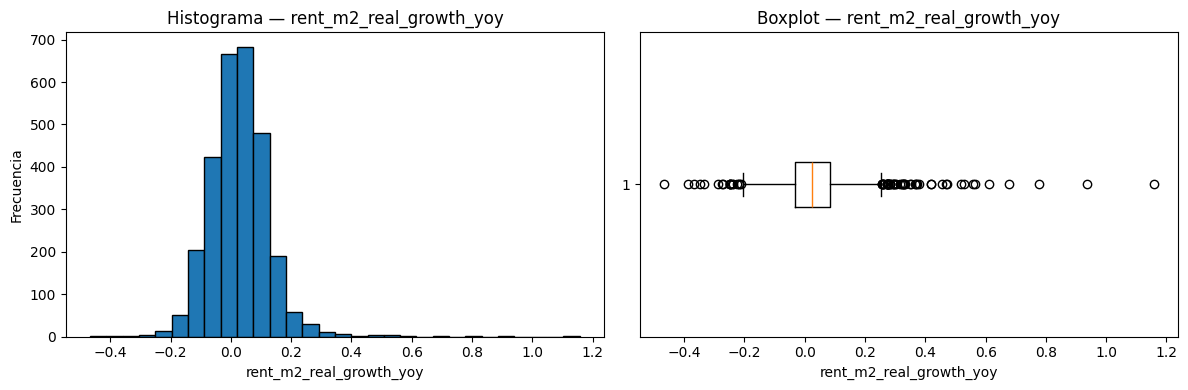

,metric,value
0,n_obs,2838.000000
1,mean,0.027457
2,std,0.099681
3,min,-0.466639
4,p01,-0.187485
5,p05,-0.114198
6,p25,-0.032269
7,median,0.024118
8,p75,0.082055
9,p95,0.171490


In [15]:
# inspeccionar rent_m2_real_growth_yoy
inspect_outcome_distribution(df_barrios_eda, "rent_m2_real_growth_yoy")

### Visualizar

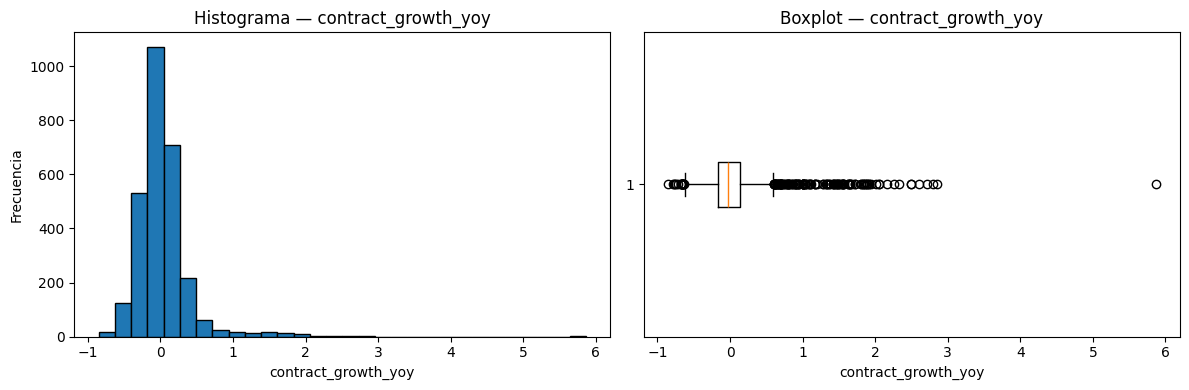

,metric,value
0,n_obs,2838.000000
1,mean,0.028791
2,std,0.382716
3,min,-0.849383
4,p01,-0.584987
5,p05,-0.402331
6,p25,-0.168897
7,median,-0.023810
8,p75,0.140295
9,p95,0.553333


In [16]:
# inspeccionar contract growth_yoy
inspect_outcome_distribution(df_barrios_eda, "contract_growth_yoy")

### Ver los barrios con observaciones extremas

In [17]:
df_barrios_eda[["neighborhood_code", "neighborhood", "year", "quarter", "contract_growth_yoy"]] \
    .sort_values("contract_growth_yoy", ascending=False) \
    .head(10)

,neighborhood_code,neighborhood,year,quarter,contract_growth_yoy
2905,69,Diagonal Mar i el Front Marítim del Poblenou,2023,3,5.864407
2874,69,Diagonal Mar i el Front Marítim del Poblenou,2015,4,2.857143
1815,40,Montbau,2021,2,2.8
687,16,la Bordeta,2021,2,2.71875
3090,73,la Verneda i la Pau,2022,4,2.607595
2332,55,Ciutat Meridiana,2021,2,2.5
1110,25,Sant Gervasi - la Bonanova,2021,2,2.488095
1863,41,la Vall d'Hebron,2021,3,2.333333
76,2,el Barri Gòtic,2021,2,2.261364
2875,69,Diagonal Mar i el Front Marítim del Poblenou,2016,1,2.166667


In [18]:
df_barrios_eda[["neighborhood_code", "neighborhood", "year", "quarter", "rent_m2_real_growth_yoy"]] \
    .sort_values("rent_m2_real_growth_yoy", ascending=False) \
    .head(10)

,neighborhood_code,neighborhood,year,quarter,rent_m2_real_growth_yoy
944,22,"Vallvidrera, el Tibidabo i les Planes",2015,1,1.157392
949,22,"Vallvidrera, el Tibidabo i les Planes",2016,2,0.936591
694,16,la Bordeta,2023,1,0.778487
1605,36,la Font d'en Fargues,2015,4,0.678957
3091,73,la Verneda i la Pau,2023,1,0.611858
1606,36,la Font d'en Fargues,2016,1,0.565459
951,22,"Vallvidrera, el Tibidabo i les Planes",2016,4,0.558521
695,16,la Bordeta,2023,2,0.527583
946,22,"Vallvidrera, el Tibidabo i les Planes",2015,3,0.517472
971,22,"Vallvidrera, el Tibidabo i les Planes",2021,4,0.473015


### Conclusión sobre la distribución y valores extremos de las variables dependientes

El análisis de la distribución de las dos variables dependientes muestra diferencias importantes en términos de estabilidad y presencia de valores extremos.

En primer lugar, `rent_m2_real_growth_yoy` presenta una distribución relativamente concentrada alrededor de cero, con una media cercana al **2.7%** y una desviación estándar moderada. Aunque se observan algunos valores extremos, especialmente en la cola derecha, la mayor parte de las observaciones se concentra en un rango razonable. De acuerdo con el criterio del rango intercuartílico, esta variable presenta **68 observaciones extremas**, equivalentes aproximadamente al **2.4%** del total. En consecuencia, puede considerarse una variable relativamente estable y adecuada para su uso como variable dependiente en modelos de panel.

En cambio, `contract_growth_yoy` muestra una distribución mucho más dispersa y claramente más asimétrica. Aunque su media también se sitúa en torno al **2.9%**, la desviación estándar es sustancialmente mayor y la cola derecha es mucho más pronunciada. El análisis por IQR identifica **147 observaciones extremas**, lo que representa aproximadamente el **5.2%** de la muestra. Además, los percentiles superiores y el valor máximo indican la presencia de episodios de crecimiento interanual muy elevados en determinados barrios y trimestres.

Este patrón no debe interpretarse automáticamente como un problema de calidad de datos. En mercados de alquiler desagregados territorialmente, especialmente cuando se trabaja a nivel de barrio y con tasas de crecimiento interanual, es esperable encontrar una mayor frecuencia de valores extremos. Esto puede deberse a la propia heterogeneidad del mercado, a efectos base cuando el volumen de contratos del año anterior es bajo, y a dinámicas puntuales de recuperación o contracción tras shocks relevantes como la pandemia. Por tanto, los valores extremos observados en `contract_growth_yoy` son plausiblemente consistentes con la naturaleza del fenómeno analizado.

Desde un punto de vista metodológico, esta evidencia sugiere que `rent_m2_real_growth_yoy` constituye una variable dependiente más estable, mientras que `contract_growth_yoy` requiere una interpretación econométrica más cautelosa. No obstante, dado que el análisis descriptivo previo sugiere que los mayores cambios tras la regulación se observan precisamente en la actividad contractual, resulta pertinente mantener `contract_growth_yoy` como outcome central del análisis sustantivo.

Por ello, la estrategia más adecuada para este trabajo será estimar los modelos principales utilizando `contract_growth_yoy` en su forma original, acompañando la inferencia con **errores estándar clusterizados por barrio** para corregir heterocedasticidad y dependencia intra-unidad. Adicionalmente, se incorporará una comprobación de robustez sencilla mediante una versión **winsorizada** de la variable, con el objetivo de verificar que los resultados no dependan de forma excesiva de unas pocas observaciones extremas. Esta solución permite mantener una especificación interpretable y metodológicamente razonable, sin introducir transformaciones más complejas que no resultan necesarias para los objetivos del TFM.

## 1.4 Serie temporal promedio por trimestre

In [19]:
def plot_mean_outcome_over_time(df, date_col, outcome_col):
    """
    Grafica la media trimestral de un outcome.
    """
    temp = (
        df.groupby(date_col, observed=False)[outcome_col]
        .mean()
        .reset_index()
        .sort_values(date_col)
    )

    plt.figure(figsize=(12, 4))
    plt.plot(temp[date_col], temp[outcome_col], marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(f"Media trimestral de {outcome_col}")
    plt.xlabel("Fecha")
    plt.ylabel(outcome_col)
    plt.show()

    return temp

In [20]:
def summarize_outcome_by_period(df, period_col, outcome_col):
    """
    Resume media, mediana y dispersión de un outcome por periodo.
    """
    summary = (
        df.groupby(period_col, observed=False)[outcome_col]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )
    return summary

In [21]:
def boxplot_outcome_by_period(df, period_col, outcome_col):
    """
    Boxplot de un outcome por periodos.
    """
    order = df[period_col].cat.categories if str(df[period_col].dtype) == "category" else None

    plt.figure(figsize=(10, 4))
    df.boxplot(column=outcome_col, by=period_col, grid=False)
    plt.title(f"{outcome_col} por {period_col}")
    plt.suptitle("")
    plt.xlabel(period_col)
    plt.ylabel(outcome_col)
    plt.xticks(rotation=20)
    plt.show()

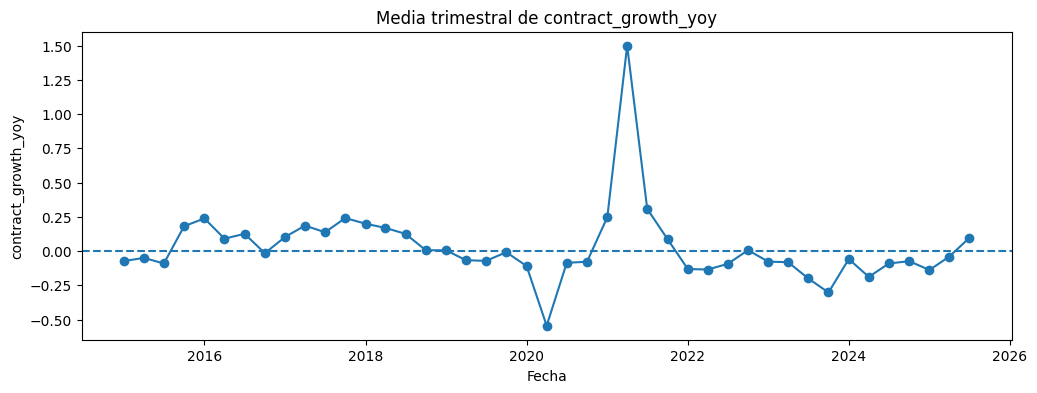

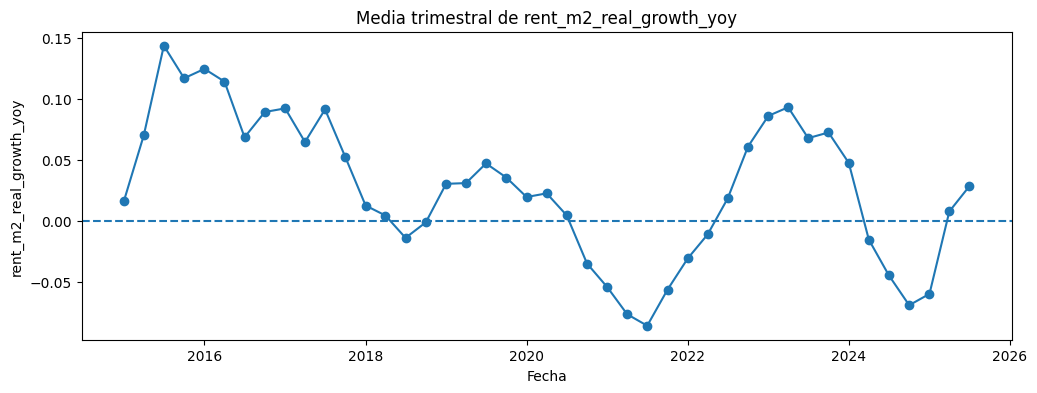

,date,rent_m2_real_growth_yoy
0,2014-01-01,NaN
1,2014-04-01,NaN
2,2014-07-01,NaN
3,2014-10-01,NaN
4,2015-01-01,0.016363
5,2015-04-01,0.070294
6,2015-07-01,0.143839
7,2015-10-01,0.117120
8,2016-01-01,0.124810
9,2016-04-01,0.114388


In [22]:
plot_mean_outcome_over_time(df_barrios_eda, "date", "contract_growth_yoy")
plot_mean_outcome_over_time(df_barrios_eda, "date", "rent_m2_real_growth_yoy")

<Figure size 1000x400 with 0 Axes>

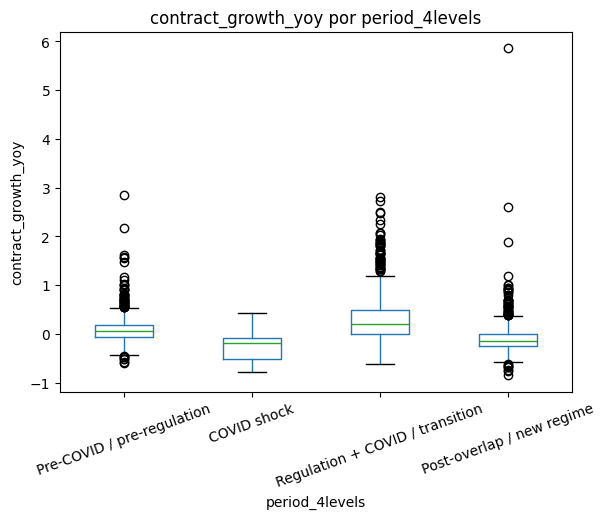

In [23]:
boxplot_outcome_by_period(df_barrios_eda, "period_4levels", "contract_growth_yoy")

<Figure size 1000x400 with 0 Axes>

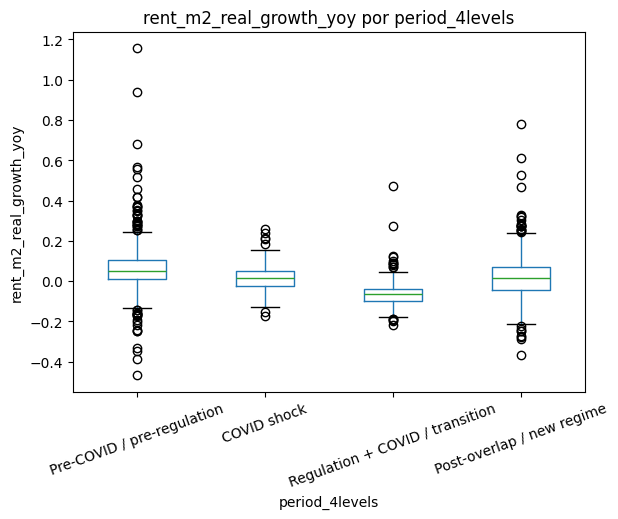

In [24]:
boxplot_outcome_by_period(df_barrios_eda, "period_4levels", "rent_m2_real_growth_yoy")

In [25]:
summarize_outcome_by_period(df_barrios_eda, "period_4levels", "contract_growth_yoy")


,period_4levels,count,mean,median,std,min,max
0,Pre-COVID / pre-regulation,1320,0.071382,0.047619,0.248935,-0.605882,2.857143
1,COVID shock,198,-0.247063,-0.188592,0.258488,-0.791667,0.416667
2,Regulation + COVID / transition,330,0.412395,0.209038,0.641985,-0.62069,2.8
3,Post-overlap / new regime,990,-0.100696,-0.140782,0.321813,-0.849383,5.864407


In [26]:
summarize_outcome_by_period(df_barrios_eda, "period_4levels", "rent_m2_real_growth_yoy")

,period_4levels,count,mean,median,std,min,max
0,Pre-COVID / pre-regulation,1320,0.059583,0.052198,0.097340,-0.466639,1.157392
1,COVID shock,198,0.015529,0.013605,0.064378,-0.170747,0.258106
2,Regulation + COVID / transition,330,-0.061810,-0.065334,0.063639,-0.217924,0.473015
3,Post-overlap / new regime,990,0.016763,0.016276,0.097539,-0.368864,0.778487


### Conclusión sobre la dinámica temporal y los quiebres visuales

El análisis conjunto de las series temporales agregadas, los boxplots por periodos y los resúmenes estadísticos confirma que las dos variables dependientes reaccionan de manera distinta al cambio de contexto iniciado en 2020.

En primer lugar, `contract_growth_yoy` presenta la ruptura temporal más marcada. Durante la etapa **Pre-COVID / pre-regulation**, el crecimiento interanual de contratos era, en promedio, positivo (media = 0.071; mediana = 0.048). Sin embargo, en el periodo **COVID shock** se observa una caída abrupta hacia valores claramente negativos (media = -0.247; mediana = -0.189), lo que refleja una contracción intensa de la actividad contractual. Posteriormente, en la fase **Regulation + COVID / transition**, la variable muestra un rebote extraordinariamente fuerte (media = 0.412; mediana = 0.209), acompañado además de la mayor dispersión de todo el periodo analizado (std = 0.642). Finalmente, en el periodo **Post-overlap / new regime**, la distribución vuelve a centrarse en valores ligeramente negativos (media = -0.101; mediana = -0.141), lo que sugiere una normalización posterior al rebote, aunque en un nivel más débil que el observado antes de 2020.

En segundo lugar, `rent_m2_real_growth_yoy` muestra una dinámica más gradual. Antes de 2020 predominaban tasas positivas de crecimiento real del alquiler por metro cuadrado (media = 0.060; mediana = 0.052). Durante el **COVID shock**, el crecimiento se desacelera de forma visible, aunque sin entrar todavía en una contracción intensa (media = 0.016; mediana = 0.014). La fase **Regulation + COVID / transition** constituye el punto de mayor debilitamiento, ya que la variable pasa a valores negativos (media = -0.062; mediana = -0.065). En el periodo **Post-overlap / new regime**, se observa una recuperación parcial hacia niveles apenas positivos (media = 0.018; mediana = 0.016), aunque sin alcanzar la intensidad expansiva del periodo pre-COVID.

En conjunto, estos resultados indican que el principal ajuste del mercado tras 2020 se manifiesta en la **actividad contractual**, que responde de forma más brusca, volátil y no lineal. Por el contrario, los **precios reales del alquiler por metro cuadrado** muestran un patrón de ajuste más gradual y persistente. Esta diferencia es sustantivamente relevante, ya que sugiere que el mercado pudo haber absorbido primero el cambio de contexto mediante ajustes en la cantidad de contratos, mientras que la corrección en precios se habría producido de manera más lenta.

Desde el punto de vista metodológico, esta evidencia refuerza dos decisiones del diseño empírico. Primero, `contract_growth_yoy` debe mantenerse como outcome central del análisis, dado que es la variable donde se observa el cambio más intenso en la dinámica del mercado. Segundo, la división en cuatro periodos resulta especialmente útil, ya que permite distinguir entre el shock pandémico inicial, la fase transitoria en la que regulación y COVID aún se superponen, y el régimen posterior más estabilizado. Una comparación simple pre/post ocultaría esta secuencia y mezclaría episodios temporalmente muy distintos.

# 2. Heterogeneidad entre barrios

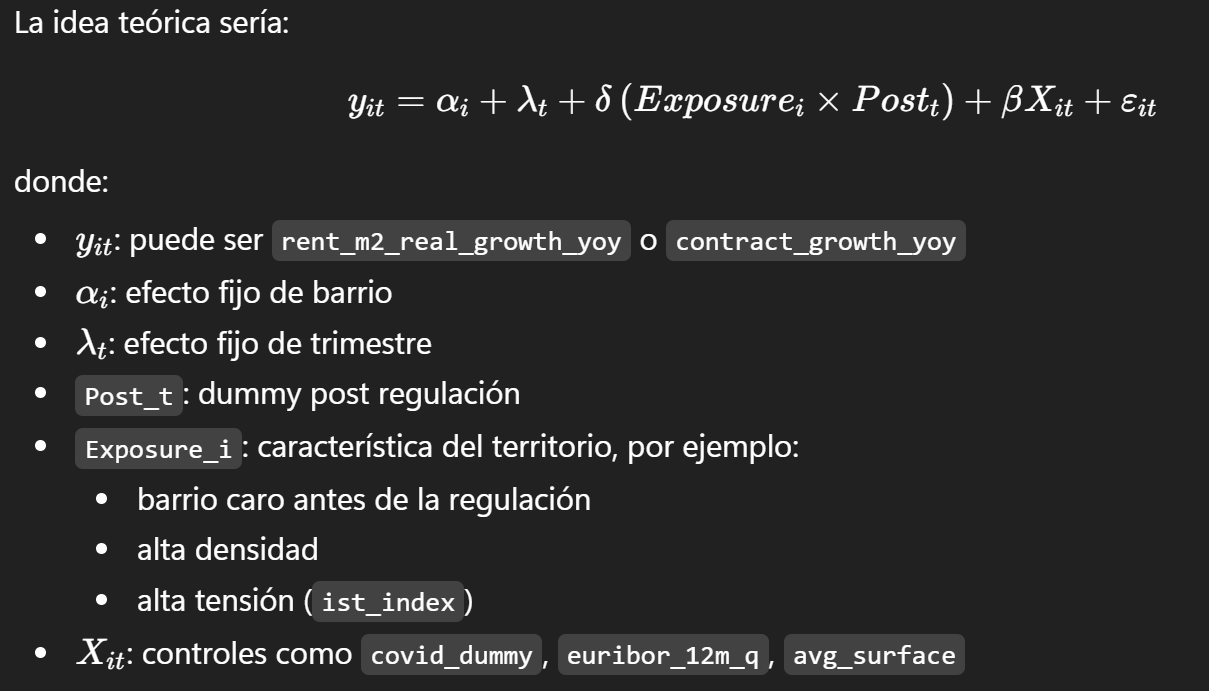



**1. Modelo principal parsimonioso**
Usar period_prepost solo como primera aproximación:

contract_growth_yoy ~ barrio FE + time FE + Exposure_i × post_regulation
control dinámico: avg_surface

Esto te da una lectura simple.

**2. Modelo extendido**
Luego pasar al modelo bueno de verdad con period_4levels:

base: Pre-COVID / pre-regulation
interacciones:

- Exposure_i × COVID shock
- Exposure_i × Regulation + COVID / transition
- Exposure_i × Post-overlap / new regime

Este es el que mejor refleja tu historia temporal.

**Outcomes**

Yo haría este orden:

principal: contract_growth_yoy
complementario: rent_m2_real_growth_yoy

Porque el EDA mostró que el mayor cambio visible está en contratos, pero precios te sirve como contraste más estable.

Robustez mínima

**Solo haría dos robusteces:**

repetir el modelo con contract_growth_yoy winsorizada
repetir el modelo con rent_m2_real_growth_yoy

Con eso ya estás muy bien para un TFM.


**Empezaría por este pipeline**

construir high_pressure_pre
correr modelo FE pre/post
correr modelo FE con 4 periodos
repetir ambos con contract_growth_yoy winsorizada
replicar el modelo extendido con rent_m2_real_growth_yoy

## Construcción de high_pressure_pre

In [27]:
# 1) Promedio pre de renta real €/m2 por barrio
pressure_pre = (
    df_barrios_eda.loc[
        df_barrios_eda["period_4levels"] == "Pre-COVID / pre-regulation",
        ["neighborhood_code", "avg_rent_m2_real_2025base"]
    ]
    .groupby("neighborhood_code", as_index=False)
    .mean()
    .rename(columns={"avg_rent_m2_real_2025base": "avg_rent_m2_real_pre"})
)

# 2) Mediana entre barrios
median_pre = pressure_pre["avg_rent_m2_real_pre"].median()

# 3) Dummy de alta presión inicial
pressure_pre["high_pressure_pre"] = (
    pressure_pre["avg_rent_m2_real_pre"] > median_pre
).astype(int)

# 4) Merge al dataframe principal
df_barrios_eda = df_barrios_eda.merge(
    pressure_pre[["neighborhood_code", "avg_rent_m2_real_pre", "high_pressure_pre"]],
    on="neighborhood_code",
    how="left"
)



In [28]:
# 5) Chequeo rápido
df_barrios_eda[["neighborhood_code", "neighborhood", "avg_rent_m2_real_pre", "high_pressure_pre"]].drop_duplicates().head(10)

,neighborhood_code,neighborhood,avg_rent_m2_real_pre,high_pressure_pre
0,1,el Raval,15.723451,1
47,2,el Barri Gòtic,15.924022,1
94,3,la Barceloneta,21.506069,1
141,4,"Sant Pere, Santa Caterina i la Ribera",17.339157,1
188,5,el Fort Pienc,15.048673,1
235,6,la Sagrada Família,15.556683,1
282,7,la Dreta de l'Eixample,15.710487,1
329,8,l'Antiga Esquerra de l'Eixample,15.849796,1
376,9,la Nova Esquerra de l'Eixample,15.688990,1
423,10,Sant Antoni,15.082732,1


In [29]:
df_barrios_eda[["neighborhood_code", "high_pressure_pre"]].drop_duplicates()["high_pressure_pre"].value_counts()

high_pressure_pre
1    33
0    33
Name: count, dtype: int64

### Construcción de la variable `high_pressure_pre`

Con el objetivo de introducir heterogeneidad territorial en el modelo econométrico, se construyó la variable `high_pressure_pre` como una medida simple de **exposición estructural previa a la regulación**.

De forma precisa, `high_pressure_pre` es una variable dicotómica definida a nivel de barrio, construida en dos pasos. En primer lugar, para cada barrio se calculó el **promedio de `avg_rent_m2_real_2025base`** durante el periodo **Pre-COVID / pre-regulation**, es decir, antes de la entrada en vigor de la regulación y antes del shock pandémico. Este promedio resume el nivel inicial de renta real por metro cuadrado del barrio en la etapa previa al cambio de régimen. En segundo lugar, se calculó la **mediana de dicho promedio entre todos los barrios** y se clasificó cada unidad territorial de la siguiente manera:

- `high_pressure_pre = 1` si el barrio presenta un nivel medio pre-regulación de renta real por m² **superior a la mediana** del conjunto de barrios.
- `high_pressure_pre = 0` si el barrio presenta un nivel medio pre-regulación de renta real por m² **igual o inferior a la mediana**.

En consecuencia, esta variable no mide presión del mercado en sentido causal estricto, sino que funciona como una **proxy operativa de mayor tensión inicial del mercado de alquiler**. La lógica subyacente es que los barrios con niveles de alquiler real por m² más elevados antes de la regulación pueden interpretarse como territorios con una situación inicial de mayor presión relativa.

Este paso es importante dentro del modelo porque, al afectar la regulación a toda Barcelona, no existe un grupo interno de control no tratado. Por ello, el análisis econométrico no puede basarse únicamente en comparar un periodo antes y después de la política, sino que debe centrarse en si **distintos tipos de barrios reaccionaron de manera diferente tras el cambio de contexto**. En este marco, `high_pressure_pre` permite introducir una dimensión clara de heterogeneidad territorial: comparar si los barrios inicialmente más tensionados evolucionan de forma distinta a los barrios inicialmente menos tensionados.

Además, esta variable se construye exclusivamente con información previa al tratamiento, lo que evita contaminar la clasificación territorial con dinámicas posteriores a la regulación. Desde el punto de vista metodológico, esto la convierte en una variable de exposición especialmente adecuada para interactuar con las fases temporales del modelo, ya sea en una especificación simple pre/post o en una especificación más rica con los cuatro periodos definidos en el análisis.

#### Por qué rent_m2_real tiene sentido

Primero, usar precio por m² es mejor que usar renta total porque aproxima mejor la intensidad del precio de uso del espacio, y no queda contaminado por diferencias en tamaño medio de vivienda entre barrios.

Segundo, usar renta real en vez de nominal es metodológicamente más consistente porque quieres que la exposición refleje una presión económica comparable entre barrios antes de la regulación, no simplemente diferencias monetarias arrastradas por inflación. Si lo que estás tratando de capturar es qué barrios ya estaban más tensionados en términos “reales”, entonces deflactar tiene bastante lógica.

Tercero, al construir una variable de heterogeneidad, conviene que sea una medida estructural, estable y pretratamiento. La renta real por m² cumple bastante bien eso: resume el nivel de tensión del mercado antes del cambio de régimen y no depende tanto de fluctuaciones coyunturales de corto plazo.

# 3. Modelos

## MODELO 1

In [30]:
# =========================================================
# MODELO 1 — FE barrio + FE tiempo
# Outcome: contract_growth_yoy
# =========================================================



# 1) Copia de trabajo
df_m1 = df_barrios_eda.copy()
# covertir a float para evitar problemas en la estimación y convertir fecha a formato datetime para facilitar manejo de efectos fijos de tiempo
df_m1["avg_surface"] = df_m1["avg_surface"].astype(float)
df_m1["date"] = pd.to_datetime(df_m1["date"])

# 2) Variables numéricas para que la interacción quede explícita
df_m1["high_pressure_pre"] = df_m1["high_pressure_pre"].astype(int)
df_m1["post_regulation_int"] = df_m1["post_regulation"].astype(int)

# 3) Muestra del modelo
model_vars = [
    "contract_growth_yoy",
    "high_pressure_pre",
    "post_regulation_int",
    "avg_surface",
    "neighborhood_code",
    "date"
]

df_m1 = df_m1[model_vars].dropna().copy()

# 4) Estimación
# C(neighborhood_code) = efectos fijos de barrio
# C(date) = efectos fijos de tiempo
model_1 = smf.ols(
    formula="""
        contract_growth_yoy ~
        high_pressure_pre:post_regulation_int +
        avg_surface +
        C(neighborhood_code) +
        C(date)
    """,
    data=df_m1
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m1["neighborhood_code"]}
)

# 5) Resumen completo
print(model_1.summary())

                             OLS Regression Results                            
Dep. Variable:     contract_growth_yoy   R-squared:                       0.541
Model:                             OLS   Adj. R-squared:                  0.522
Method:                  Least Squares   F-statistic:                     982.0
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           6.90e-78
Time:                         15:20:49   Log-Likelihood:                -196.74
No. Observations:                 2838   AIC:                             613.5
Df Residuals:                     2728   BIC:                             1268.
Df Model:                          109                                         
Covariance Type:               cluster                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

c:\Users\jrort\venv312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 109, but rank is 44
  warnings.warn('covariance of constraints does not have full '


In [31]:
df_m1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2838 entries, 4 to 3101
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   contract_growth_yoy  2838 non-null   Float64       
 1   high_pressure_pre    2838 non-null   int64         
 2   post_regulation_int  2838 non-null   int64         
 3   avg_surface          2838 non-null   float64       
 4   neighborhood_code    2838 non-null   int64         
 5   date                 2838 non-null   datetime64[ns]
dtypes: Float64(1), datetime64[ns](1), float64(1), int64(3)
memory usage: 158.0 KB


### Interpretación crítica del Modelo 1

El primer modelo estimado debe entenderse como una **especificación inicial y orientativa**, útil para explorar patrones generales, pero todavía insuficiente como evidencia sólida de heterogeneidad territorial. Aunque el ajuste global parece razonable a primera vista, una lectura más cuidadosa muestra varias limitaciones importantes.

#### 1. Coeficiente de interés principal

El coeficiente clave del modelo es la interacción:

\[
high\_pressure\_pre_i \times post\_regulation_t
\]

Su valor estimado es:

- **coeficiente:** -0.0248  
- **error estándar:** 0.016  
- **p-value:** 0.128  
- **intervalo de confianza al 95%:** [-0.057, 0.007]

La lectura sustantiva de este coeficiente sería la siguiente: en esta especificación simple pre/post, los barrios clasificados como de **alta presión inicial** habrían presentado, en promedio, un crecimiento interanual de contratos aproximadamente **2.48 puntos porcentuales menor** en el periodo post-regulación que los barrios de baja presión, una vez controladas las diferencias fijas entre barrios y los shocks comunes de cada trimestre.

Sin embargo, este resultado **no es estadísticamente significativo** a niveles convencionales. Por tanto, siendo estrictos, este modelo **no aporta evidencia robusta** para afirmar que los barrios con mayor presión inicial reaccionaron de forma diferencial tras la regulación en términos de crecimiento de contratos.

#### 2. R-squared y capacidad explicativa

El modelo presenta:

- **R-squared:** 0.541  
- **Adjusted R-squared:** 0.522

A primera vista, estos valores podrían parecer satisfactorios. No obstante, en un modelo con un gran número de **efectos fijos territoriales y temporales**, el R² debe interpretarse con cautela. Una parte importante de la capacidad explicativa del modelo probablemente proviene de las dummies de tiempo y de barrio, y no necesariamente de la variable sustantiva central.

En otras palabras, el hecho de que el modelo explique alrededor del 54% de la variación de `contract_growth_yoy` no implica que la interacción `high_pressure_pre × post_regulation` esté explicando una parte relevante de esa variación. De hecho, dado que dicho coeficiente no es significativo, no sería correcto utilizar el R² como argumento a favor de la hipótesis principal.

#### 3. Significancia global del modelo

El output reporta:

- **F-statistic:** 982.0  
- **Prob (F-statistic):** aproximadamente 0

Esto indica que, en conjunto, el modelo tiene capacidad explicativa. Sin embargo, esta lectura también debe matizarse. El modelo incluye una gran cantidad de parámetros, especialmente efectos fijos, y además aparece una advertencia técnica relacionada con la matriz de covarianzas clusterizadas:

> covariance of constraints does not have full rank

Esto sugiere que la inferencia conjunta del modelo no debe interpretarse de manera excesivamente optimista. En consecuencia, aunque el modelo globalmente captura patrones sistemáticos en los datos, esto **no equivale** a demostrar la hipótesis de heterogeneidad territorial que realmente interesa.

#### 4. Papel dominante de los efectos temporales

Uno de los rasgos más evidentes del modelo es el fuerte peso de los **efectos fijos temporales**. Muchos coeficientes asociados a `C(date)` son grandes y altamente significativos. Por ejemplo:

- 2020-04-01: coeficiente fuertemente negativo  
- 2021-04-01: coeficiente fuertemente positivo  
- varios trimestres de 2021 también muestran efectos positivos elevados

Este patrón es plenamente coherente con el análisis exploratorio previo y refleja la secuencia ya observada en los datos: caída abrupta en la actividad contractual durante el shock pandémico, fuerte rebote posterior y normalización posterior.

La implicación metodológica es importante: el modelo está capturando con claridad los **shocks comunes del tiempo**, pero precisamente por eso una especificación simple basada únicamente en `post_regulation` puede estar siendo demasiado burda para identificar la heterogeneidad que se busca.

#### 5. Interpretación de `avg_surface`

El coeficiente estimado para `avg_surface` es:

- **coeficiente:** 0.0022  
- **p-value:** 0.397

La interpretación literal sería que un aumento de un metro cuadrado en la superficie media se asocia con un incremento de aproximadamente 0.22 puntos porcentuales en el crecimiento interanual de contratos. No obstante, este efecto es pequeño y además estadísticamente no significativo.

Por tanto, en esta especificación concreta, `avg_surface` no parece desempeñar un papel central como variable de control explicativa.

#### 6. Diagnóstico de residuos

Los estadísticos de residuos muestran un comportamiento claramente no normal:

- **Omnibus:** muy elevado  
- **Jarque-Bera:** extremadamente elevado  
- **Skew:** 5.467  
- **Kurtosis:** 105.696  
- **p-values:** 0.00

Esto indica que los residuos presentan una fuerte asimetría y colas extremadamente pesadas. En parte, esto era esperable, dado que `contract_growth_yoy` es una variable muy volátil y con presencia de observaciones extremas. Por tanto, estos resultados no invalidan automáticamente el modelo, pero sí refuerzan la idea de que la variable dependiente presenta una estructura complicada, con outliers y episodios de fuerte rebote o contracción.

En este contexto, el uso de **errores estándar clusterizados por barrio** resulta adecuado para mejorar la inferencia, aunque no elimina el problema de los valores extremos. Por ello, sigue siendo recomendable complementar este modelo con una versión winsorizada como análisis de robustez.

#### 7. Autocorrelación y dependencia temporal

El estadístico **Durbin-Watson = 1.662** sugiere cierta autocorrelación positiva en los residuos. Aunque este valor no apunta a un problema extremo, sí indica que los errores no son completamente independientes en el tiempo.

En términos prácticos, esta evidencia respalda aún más la decisión de utilizar **errores estándar clusterizados por barrio**, ya que la independencia clásica de los residuos no parece cumplirse estrictamente.

#### 8. Número de condición y posibles problemas numéricos

El modelo presenta un:

- **Condition Number:** 4.93e+03

Este valor es relativamente alto y puede ser indicativo de diferencias de escala entre variables, presencia de muchas dummies o cierta colinealidad. En este caso, es probable que el problema se deba principalmente a la inclusión simultánea de numerosos efectos fijos de barrio y tiempo, más que a una colinealidad sustantiva severa entre regresores.

Aun así, este resultado sugiere que el modelo no es particularmente elegante desde el punto de vista numérico y que su interpretación debe hacerse con prudencia.

### Balance general del modelo

En conjunto, este primer modelo tiene algunos elementos positivos: captura de forma razonable los shocks temporales, utiliza una estructura de efectos fijos coherente con el diseño empírico y está alineado con los hallazgos previos del análisis exploratorio. Sin embargo, también presenta debilidades claras: la variable central de interés no resulta significativa, los residuos se apartan fuertemente de la normalidad, existen advertencias numéricas y buena parte del ajuste parece venir de los efectos fijos temporales más que de la heterogeneidad territorial que se pretende estudiar.

Por tanto, este modelo **no debería presentarse como evidencia concluyente de heterogeneidad territorial**. Más bien, debe interpretarse como una primera aproximación que no encuentra evidencia robusta de un efecto diferencial entre barrios de alta y baja presión en una especificación simple pre/post.

### Conclusión metodológica

La principal conclusión de este ejercicio es que la dinámica del mercado parece ser **más compleja que una simple comparación antes/después**. La falta de significancia del término de interacción sugiere que la heterogeneidad territorial, si existe, probablemente no se expresa de forma uniforme en todo el periodo post-regulación, sino que podría estar siendo promediada y diluida por la coexistencia de fases temporales muy distintas.

En consecuencia, el siguiente paso metodológicamente más razonable es estimar una especificación más rica, basada en los **cuatro periodos temporales definidos previamente**, para comprobar si la respuesta diferencial de los barrios de alta presión inicial emerge con mayor claridad al distinguir entre shock COVID, fase de transición y nuevo régimen posterior.

## MODELO 2 — FE barrio + FE tiempo + interacciones por 4 periodos NO FUNCIONA

In [32]:
# =========================================================
# MODELO 2 — FE barrio + FE tiempo + interacciones por 4 periodos
# Outcome: contract_growth_yoy
# =========================================================


# 1) Copia de trabajo
df_m2 = df_barrios_eda.copy()

# 2) Tipos
df_m2["contract_growth_yoy"] = df_m2["contract_growth_yoy"].astype(float)
df_m2["high_pressure_pre"] = df_m2["high_pressure_pre"].astype(int)
df_m2["date"] = pd.to_datetime(df_m2["date"])

# 3) Orden explícito de periodos
period_order = [
    "Pre-COVID / pre-regulation",
    "COVID shock",
    "Regulation + COVID / transition",
    "Post-overlap / new regime"
]

df_m2["period_4levels"] = pd.Categorical(
    df_m2["period_4levels"],
    categories=period_order,
    ordered=True
)

# 4) Muestra
model_vars = [
    "contract_growth_yoy",
    "high_pressure_pre",
    "period_4levels",
    "neighborhood_code",
    "date"
]

df_m2 = df_m2[model_vars].dropna().copy()

# 5) Modelo
model_2 = smf.ols(
    formula="""
        contract_growth_yoy ~
        high_pressure_pre:C(period_4levels, Treatment(reference="Pre-COVID / pre-regulation")) +
        C(neighborhood_code) +
        C(date)
    """,
    data=df_m2
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m2["neighborhood_code"]}
)

print(model_2.summary())

                             OLS Regression Results                            
Dep. Variable:     contract_growth_yoy   R-squared:                       0.542
Model:                             OLS   Adj. R-squared:                  0.523
Method:                  Least Squares   F-statistic:                 2.593e-13
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):               1.00
Time:                         15:20:49   Log-Likelihood:                -193.38
No. Observations:                 2838   AIC:                             608.8
Df Residuals:                     2727   BIC:                             1269.
Df Model:                          110                                         
Covariance Type:               cluster                                         
                                                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------

c:\Users\jrort\venv312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 111, but rank is 1
  warnings.warn('covariance of constraints does not have full '


## MODELO 2 REESPECIFICADO

In [33]:

# MODELO 2 REESPECIFICADO
# FE barrio + FE tiempo + 3 interacciones manuales
# Outcome: contract_growth_yoy
# Base omitida: Pre-COVID / pre-regulation
# =========================================================

# 1) Copia de trabajo
df_m2b = df_barrios_eda.copy()

# 2) Tipos
df_m2b["contract_growth_yoy"] = df_m2b["contract_growth_yoy"].astype(float)
df_m2b["high_pressure_pre"] = df_m2b["high_pressure_pre"].astype(int)
df_m2b["neighborhood_code"] = df_m2b["neighborhood_code"].astype(int)
df_m2b["date"] = pd.to_datetime(df_m2b["date"])

# 3) Dummies de fase temporal
df_m2b["covid_shock"] = (
    df_m2b["period_4levels"] == "COVID shock"
).astype(int)

df_m2b["transition_regcovid"] = (
    df_m2b["period_4levels"] == "Regulation + COVID / transition"
).astype(int)

df_m2b["new_regime"] = (
    df_m2b["period_4levels"] == "Post-overlap / new regime"
).astype(int)

# 4) Interacciones manuales con la exposure
df_m2b["hp_x_covid"] = df_m2b["high_pressure_pre"] * df_m2b["covid_shock"]
df_m2b["hp_x_transition"] = df_m2b["high_pressure_pre"] * df_m2b["transition_regcovid"]
df_m2b["hp_x_newregime"] = df_m2b["high_pressure_pre"] * df_m2b["new_regime"]

# 5) Muestra del modelo
model_vars = [
    "contract_growth_yoy",
    "hp_x_covid",
    "hp_x_transition",
    "hp_x_newregime",
    "neighborhood_code",
    "date"
]

df_m2b = df_m2b[model_vars].dropna().copy()

# 6) Estimación
model_2b = smf.ols(
    formula="""
        contract_growth_yoy ~
        hp_x_covid +
        hp_x_transition +
        hp_x_newregime +
        C(neighborhood_code) +
        C(date)
    """,
    data=df_m2b
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m2b["neighborhood_code"]}
)

print(model_2b.summary())

c:\Users\jrort\venv312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 110, but rank is 45
  warnings.warn('covariance of constraints does not have full '


                             OLS Regression Results                            
Dep. Variable:     contract_growth_yoy   R-squared:                       0.542
Model:                             OLS   Adj. R-squared:                  0.523
Method:                  Least Squares   F-statistic:                     917.3
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           4.79e-77
Time:                         15:20:49   Log-Likelihood:                -193.32
No. Observations:                 2838   AIC:                             608.6
Df Residuals:                     2727   BIC:                             1269.
Df Model:                          110                                         
Covariance Type:               cluster                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [34]:
coef_table_m2b = pd.DataFrame({
    "coef": model_2b.params,
    "std_err": model_2b.bse,
    "z": model_2b.tvalues,
    "p_value": model_2b.pvalues,
    "ci_low": model_2b.conf_int()[0],
    "ci_high": model_2b.conf_int()[1]
})

coef_table_m2b.loc[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]]

,coef,std_err,z,p_value,ci_low,ci_high
hp_x_covid,-0.043039,0.027430,-1.569039,0.116639,-0.096800,0.010723
hp_x_transition,0.046239,0.035439,1.304748,0.191979,-0.023220,0.115699
hp_x_newregime,-0.054097,0.021364,-2.532152,0.011336,-0.095969,-0.012224


### Interpretación adicional del modelo reespecificado

#### 1. El modelo quedó mucho mejor especificado

Una primera conclusión relevante es que esta reespecificación mejora de forma clara la calidad numérica del modelo respecto al intento anterior. En la versión previa aparecían coeficientes absurdamente grandes, errores estándar explosivos y señales claras de singularidad. En cambio, en esta especificación el **Condition Number = 69.7**, un valor mucho más razonable, y los coeficientes principales pasan a ser numéricamente interpretables. En consecuencia, este modelo puede considerarse una especificación econométrica usable, a diferencia de la formulación anterior.

#### 2. La heterogeneidad aparece sobre todo en el régimen posterior

El patrón más importante del modelo es que la heterogeneidad territorial no aparece de forma homogénea en todo el periodo posterior a 2020. En concreto:

- `hp_x_covid` no es estadísticamente significativo.
- `hp_x_transition` tampoco es estadísticamente significativo.
- `hp_x_newregime` sí es negativo y estadísticamente significativo.

Esto sugiere que la diferencia entre barrios de alta y baja presión inicial **no emerge ni durante el shock pandémico inicial ni durante la fase transitoria**, sino más bien en el periodo posterior, cuando el mercado entra en una fase relativamente más estable. Una lectura sustantiva razonable es que, durante COVID, el shock fue demasiado generalizado; durante la transición persistía todavía mucho rebote y volatilidad; y solo a partir de 2022Q1–2025Q3 aparece una divergencia más clara entre tipos de barrio.

#### 3. El modelo confirma la historia temporal del mercado

Los efectos fijos de tiempo están muy alineados con lo observado previamente en el análisis exploratorio. En particular:

- **2020Q2** muestra una caída muy intensa del crecimiento interanual de contratos.
- **2021Q2** presenta un rebote extraordinariamente fuerte.
- varios trimestres de 2021 muestran efectos positivos y significativos.
- algunos trimestres de 2023–2024 vuelven a reflejar cierta debilidad.

Este patrón confirma la secuencia ya identificada descriptivamente: **shock inicial, rebote posterior y normalización en una etapa más reciente**.

#### 4. El ajuste del modelo proviene principalmente del tiempo y de los efectos fijos

El modelo presenta un **R-squared = 0.542** y un **Adjusted R-squared = 0.523**, lo que indica una capacidad explicativa razonable. Sin embargo, esta capacidad no debe atribuirse automáticamente a las interacciones sustantivas. Una parte importante del ajuste parece provenir de los **efectos fijos de tiempo y de barrio**, más que de la heterogeneidad capturada por `high_pressure_pre`.

Por tanto, aunque el modelo explica una fracción importante de la variación de `contract_growth_yoy`, la contribución específica de la parte sustantiva del análisis de heterogeneidad sigue siendo relativamente acotada.

#### 5. Los efectos fijos de barrio no deben ser el foco interpretativo

Muchas dummies de barrio resultan significativas, pero no conviene darles demasiado protagonismo analítico. En un modelo con efectos fijos, estos coeficientes simplemente indican que ciertos barrios presentan niveles medios distintos del crecimiento interanual de contratos respecto al barrio base, una vez controlados los efectos temporales. Esto no constituye el hallazgo central del trabajo, ni debe interpretarse como evidencia principal sobre el impacto de la regulación.

#### 6. El intercept tiene poca relevancia sustantiva

El intercept estimado (`-0.101`) tampoco tiene una lectura económica particularmente útil. En este contexto, el intercept representa el valor esperado del outcome para el barrio base y el trimestre base, cuando las interacciones valen cero. Dado el gran número de efectos fijos incluidos, su interpretación sustantiva es muy limitada.

#### 7. Los residuos siguen mostrando problemas importantes

Los diagnósticos de residuos siguen siendo desfavorables:

- **Skew = 5.466**
- **Kurtosis = 104.922**
- **Jarque-Bera** extremadamente elevado
- p-value = 0

Esto indica que los residuos continúan siendo muy asimétricos y con colas pesadas, lo que confirma que `contract_growth_yoy` sigue siendo una variable especialmente volátil y con observaciones extremas. Este resultado no invalida el modelo, pero sí justifica mantener una lectura cautelosa e incorporar una comprobación de robustez mediante winsorización.

#### 8. Existe cierta autocorrelación, aunque no extrema

El estadístico **Durbin-Watson = 1.672** sugiere la presencia de cierta autocorrelación positiva en los residuos, aunque no de forma extrema. Esto refuerza la conveniencia de utilizar **errores estándar clusterizados por barrio**, que son consistentes con la posible dependencia temporal dentro de cada unidad territorial.

#### 9. La significancia global del modelo es buena, pero no debe sobredimensionarse

El modelo presenta:

- **F-statistic = 917.3**
- **Prob(F-statistic) ≈ 0**

Esto indica que, en conjunto, el modelo capta estructura sistemática en los datos. No obstante, esta significancia global no implica que todos los elementos sustantivos del modelo sean fuertes o concluyentes. En particular, la principal fuente de ajuste sigue siendo la combinación de efectos fijos territoriales y temporales, más que todas las interacciones de heterogeneidad por sí mismas.

---

### Balance final del modelo

En conjunto, esta especificación ya puede considerarse **econométricamente defendible**. A diferencia del intento anterior, el modelo está correctamente identificado y produce coeficientes interpretables. Desde el punto de vista sustantivo, el mensaje central es relativamente específico: no se observa evidencia clara de heterogeneidad territorial durante el shock COVID ni durante la fase transitoria, pero sí aparece una heterogeneidad negativa en el régimen posterior más estabilizado. En otras palabras, el mercado parece haberse diferenciado entre barrios de alta y baja presión inicial **más tarde**, y no de forma inmediata.

---

### Frase académica de síntesis

La evidencia sugiere que la heterogeneidad territorial asociada a la presión inicial del mercado no se manifiesta de forma robusta durante el shock pandémico ni durante la fase transitoria de solapamiento entre COVID y regulación, sino principalmente en el régimen posterior más estabilizado, donde los barrios inicialmente más tensionados presentan una dinámica contractual relativamente más débil.

## MODELO 3 Modelo 2 reespecificado con outcome winsorizado

## Winsorización de contract_growth_yoy


In [35]:

# ROBUSTEZ — Winsorización de contract_growth_yoy

# 1) Copia de trabajo
df_w = df_barrios_eda.copy()

# 2) Tipos
df_w["contract_growth_yoy"] = df_w["contract_growth_yoy"].astype(float)
df_w["high_pressure_pre"] = df_w["high_pressure_pre"].astype(int)
df_w["neighborhood_code"] = df_w["neighborhood_code"].astype(int)
df_w["date"] = pd.to_datetime(df_w["date"])

# 3) Winsorización 1% - 99%
p01 = df_w["contract_growth_yoy"].quantile(0.01)
p99 = df_w["contract_growth_yoy"].quantile(0.99)

df_w["contract_growth_yoy_winsor"] = df_w["contract_growth_yoy"].clip(lower=p01, upper=p99)

print("Percentil 1% :", p01)
print("Percentil 99%:", p99)

# 4) Dummies temporales
df_w["covid_shock"] = (df_w["period_4levels"] == "COVID shock").astype(int)
df_w["transition_regcovid"] = (
    df_w["period_4levels"] == "Regulation + COVID / transition"
).astype(int)
df_w["new_regime"] = (
    df_w["period_4levels"] == "Post-overlap / new regime"
).astype(int)

# 5) Interacciones con high_pressure_pre
df_w["hp_x_covid"] = df_w["high_pressure_pre"] * df_w["covid_shock"]
df_w["hp_x_transition"] = df_w["high_pressure_pre"] * df_w["transition_regcovid"]
df_w["hp_x_newregime"] = df_w["high_pressure_pre"] * df_w["new_regime"]

# 6) Muestra del modelo
model_vars = [
    "contract_growth_yoy_winsor",
    "hp_x_covid",
    "hp_x_transition",
    "hp_x_newregime",
    "neighborhood_code",
    "date"
]

df_w_model = df_w[model_vars].dropna().copy()



Percentil 1% : -0.5849865229110512
Percentil 99%: 1.655296572280179


In [36]:
# 7) Estimación
model_2b_w = smf.ols(
    formula="""
        contract_growth_yoy_winsor ~
        hp_x_covid +
        hp_x_transition +
        hp_x_newregime +
        C(neighborhood_code) +
        C(date)
    """,
    data=df_w_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_w_model["neighborhood_code"]}
)

print(model_2b_w.summary())

                                OLS Regression Results                                
Dep. Variable:     contract_growth_yoy_winsor   R-squared:                       0.597
Model:                                    OLS   Adj. R-squared:                  0.581
Method:                         Least Squares   F-statistic:                     879.5
Date:                        Thu, 16 Apr 2026   Prob (F-statistic):           1.87e-76
Time:                                15:20:49   Log-Likelihood:                 296.43
No. Observations:                        2838   AIC:                            -370.9
Df Residuals:                            2727   BIC:                             289.7
Df Model:                                 110                                         
Covariance Type:                      cluster                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------

c:\Users\jrort\venv312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 110, but rank is 45
  warnings.warn('covariance of constraints does not have full '


### Interpretación del summary del modelo winsorizado

El summary del modelo estimado con `contract_growth_yoy_winsor` aporta evidencia adicional de que la winsorización no solo mejora la estabilidad estadística de la estimación, sino que también refuerza la lectura sustantiva del análisis.

#### 1. El ajuste del modelo mejora de forma visible

En comparación con la especificación original sin winsorización, el modelo winsorizado presenta una mejora clara en varias métricas de ajuste:

- **R-squared** aumenta de **0.542** a **0.597**
- **Adjusted R-squared** aumenta de **0.523** a **0.581**
- **AIC** disminuye de **608.6** a **-370.9**
- **Log-Likelihood** aumenta de forma considerable

Estas diferencias indican que, una vez reducido el peso de las observaciones más extremas, el modelo describe mejor la estructura general de los datos. No implica que el modelo sea “perfecto”, pero sí sugiere que la variable dependiente winsorizada se ajusta de manera más estable a la especificación de panel propuesta.

#### 2. Los residuos mejoran notablemente, aunque no se normalizan por completo

Uno de los cambios más relevantes se observa en los diagnósticos de residuos. En el modelo original, la distribución residual mostraba una asimetría y curtosis extremadamente elevadas. Tras la winsorización:

- **Skew** baja de aproximadamente **5.47** a **1.45**
- **Kurtosis** baja de aproximadamente **104.9** a **12.56**

Esto indica una mejora sustancial en la forma de la distribución residual. Los residuos siguen estando lejos de una distribución normal, pero el problema de colas extremas se reduce de manera muy clara. En consecuencia, la winsorización parece haber cumplido precisamente el objetivo buscado: disminuir la influencia desproporcionada de observaciones extremas sin eliminar la señal central del fenómeno analizado.

#### 3. Los coeficientes clave se vuelven más claros y más robustos

La lectura de las interacciones principales se refuerza en el modelo winsorizado:

- **`hp_x_covid = -0.045`**, con *p* = **0.079**  
  El signo sigue siendo negativo y el resultado se aproxima a significancia estadística, aunque todavía no alcanza el umbral convencional del 5%.

- **`hp_x_transition = 0.061`**, con *p* = **0.036**  
  El coeficiente se vuelve positivo y estadísticamente significativo, lo que sugiere una dinámica contractual relativamente mejor en los barrios de alta presión inicial durante la fase de transición.

- **`hp_x_newregime = -0.059`**, con *p* = **0.004**  
  Este resultado es especialmente importante, ya que el efecto negativo en el régimen posterior no solo se mantiene, sino que se vuelve más fuerte y más significativo.

En términos sustantivos, esto refuerza la idea de una secuencia temporal diferenciada: una señal negativa durante el shock inicial, una fase transitoria relativamente favorable para los barrios de alta presión, y un deterioro posterior más claro y robusto en el nuevo régimen estabilizado.

#### 4. La historia temporal general del mercado se mantiene

Los efectos fijos de tiempo continúan mostrando una evolución coherente con todo el análisis exploratorio realizado previamente. Entre los patrones más claros destacan:

- una caída intensa en **2020Q2**
- un rebote extraordinario en **2021Q2**
- una posterior normalización
- y cierta debilidad renovada en algunos trimestres de **2023–2024**

Esto indica que la winsorización no altera la narrativa temporal principal del mercado, sino que la preserva y la hace estadísticamente más estable.

#### 5. El modelo es interpretable y usable

Desde el punto de vista econométrico, la especificación winsorizada sigue siendo un modelo usable:

- **Condition Number = 69.7**, un valor razonable
- no aparecen señales de singularidad grave
- el warning sobre el rango incompleto de algunas restricciones sigue presente, pero en esta especificación no parece invalidar la interpretación de los coeficientes principales

En consecuencia, los coeficientes de interés sustantivo —especialmente las interacciones temporales con `high_pressure_pre`— pueden interpretarse con bastante más confianza que en especificaciones anteriores problemáticas.

#### 6. Los efectos fijos de barrio no deben sobredimensionarse

Aunque muchas dummies de barrio aparecen con significancia muy alta y errores estándar extremadamente pequeños, no conviene utilizarlas como base para una interpretación sustantiva. En un modelo con efectos fijos, estos coeficientes simplemente capturan diferencias medias persistentes entre barrios respecto a la categoría base, una vez controlado el tiempo. No constituyen el foco analítico principal del trabajo.

Por tanto, la atención debe centrarse en:

- `hp_x_covid`
- `hp_x_transition`
- `hp_x_newregime`
- y en los principales efectos temporales asociados a shock, rebote y normalización

---

### Conclusión general del modelo winsorizado

En conjunto, el summary del modelo winsorizado indica que la winsorización mejora de manera visible el comportamiento estadístico de la especificación. El ajuste global es mejor, la distribución residual se vuelve menos extrema y los coeficientes de interés adquieren una lectura más nítida.

Desde un punto de vista sustantivo, el patrón que emerge es coherente y más robusto que en el modelo original: durante la fase de transición, los barrios inicialmente más tensionados muestran una dinámica contractual relativamente más favorable, mientras que en el régimen posterior más estabilizado presentan una evolución significativamente más débil. En consecuencia, la versión winsorizada del modelo no debilita la historia empírica del trabajo, sino que la fortalece.

In [37]:
compare_key = pd.DataFrame({
    "coef_original": model_2b.params[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]],
    "p_original": model_2b.pvalues[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]],
    "coef_winsor": model_2b_w.params[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]],
    "p_winsor": model_2b_w.pvalues[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]],
})

compare_key

,coef_original,p_original,coef_winsor,p_winsor
hp_x_covid,-0.043039,0.116639,-0.045370,0.078969
hp_x_transition,0.046239,0.191979,0.061166,0.035715
hp_x_newregime,-0.054097,0.011336,-0.058543,0.004279


### Robustez del modelo mediante winsorización del crecimiento interanual de contratos

Con el fin de comprobar si los resultados del modelo estaban excesivamente influenciados por unas pocas observaciones extremas, se estimó una especificación alternativa utilizando una versión winsorizada de `contract_growth_yoy`, truncando la distribución en los percentiles 1 y 99. Esta estrategia permite reducir el peso de valores atípicos muy intensos sin alterar de forma sustancial la estructura general de la variable.

Los resultados obtenidos muestran que la lógica principal del modelo no solo se mantiene, sino que en algunos casos se vuelve más nítida. En primer lugar, el coeficiente asociado a `hp_x_newregime` permanece **negativo** y además aumenta ligeramente en magnitud, pasando de **-0.054** en el modelo original a **-0.059** en la versión winsorizada. Al mismo tiempo, su significancia estadística se refuerza, con un *p-value* que desciende de **0.011** a **0.004**. Este resultado es especialmente importante, ya que indica que el hallazgo central del análisis —una dinámica contractual relativamente más débil en los barrios de alta presión inicial durante el régimen posterior más estabilizado— no depende de un pequeño conjunto de observaciones extremas, sino que parece reflejar un patrón más general del panel.

En segundo lugar, el coeficiente de `hp_x_transition` pasa de ser **positivo pero no significativo** en el modelo original (**0.046**, *p* = 0.192) a ser **positivo y estadísticamente significativo** tras la winsorización (**0.061**, *p* = 0.036). Esta diferencia sugiere que, durante la fase de transición en la que todavía se superponen regulación y pandemia, los barrios inicialmente más tensionados podrían haber experimentado un comportamiento contractual relativamente más favorable que los barrios de menor presión inicial. La falta de significancia en la estimación original parece deberse, al menos en parte, a la influencia de observaciones extremas que introducían ruido adicional en esta fase.

Por su parte, `hp_x_covid` mantiene un signo **negativo** muy similar en ambos modelos. En la especificación original, su coeficiente era **-0.043** (*p* = 0.117), mientras que en la versión winsorizada pasa a **-0.045** (*p* = 0.079). Aunque el resultado sigue sin alcanzar significancia al 5%, sí se acerca algo más a ese umbral, lo que refuerza la idea de una posible respuesta relativamente más débil de los barrios de alta presión durante el shock inicial, aunque todavía sin evidencia concluyente.

En conjunto, la comparación entre la especificación original y la winsorizada sugiere que los resultados principales del modelo son **robustos a la presencia de valores extremos**. Más aún, la winsorización parece revelar con mayor claridad una secuencia temporal coherente: una señal negativa durante el shock pandémico, un comportamiento relativamente mejor de los barrios de alta presión en la fase transitoria, y un deterioro relativo más marcado en el régimen posterior. Esta evolución es conceptualmente plausible, ya que sugiere que los barrios inicialmente más tensionados pudieron mostrar primero una mayor capacidad de rebote en la transición, pero terminaron exhibiendo una dinámica contractual más débil una vez que el mercado entró en una etapa más estabilizada.

Desde el punto de vista metodológico, este ejercicio de robustez fortalece la credibilidad del análisis. En lugar de depender de observaciones extremas aisladas, los principales hallazgos parecen sostenerse —e incluso reforzarse— cuando se limita el peso de dichos valores. Por ello, la evidencia obtenida en la especificación winsorizada puede considerarse un respaldo importante a la interpretación sustantiva del modelo principal.

## MODELO PANEL OLS. Usando la herramienta OLS

In [38]:

# COMPARACION — PanelOLS con la especificacion final
# Outcome: contract_growth_yoy_winsor
# FE: barrio + tiempo
# SE: cluster por barrio




# 1) Copia de trabajo
df_p = df_barrios_eda.copy()

# 2) Tipos
df_p["contract_growth_yoy"] = df_p["contract_growth_yoy"].astype(float)
df_p["high_pressure_pre"] = df_p["high_pressure_pre"].astype(int)
df_p["neighborhood_code"] = df_p["neighborhood_code"].astype(int)
df_p["date"] = pd.to_datetime(df_p["date"])

# 3) Winsorizacion 1%-99% (si ya la tienes, puedes saltarte esto)
p01 = df_p["contract_growth_yoy"].quantile(0.01)
p99 = df_p["contract_growth_yoy"].quantile(0.99)
df_p["contract_growth_yoy_winsor"] = df_p["contract_growth_yoy"].clip(lower=p01, upper=p99)

# 4) Dummies de fase temporal
df_p["covid_shock"] = (df_p["period_4levels"] == "COVID shock").astype(int)
df_p["transition_regcovid"] = (
    df_p["period_4levels"] == "Regulation + COVID / transition"
).astype(int)
df_p["new_regime"] = (
    df_p["period_4levels"] == "Post-overlap / new regime"
).astype(int)

# 5) Interacciones con la exposure
df_p["hp_x_covid"] = df_p["high_pressure_pre"] * df_p["covid_shock"]
df_p["hp_x_transition"] = df_p["high_pressure_pre"] * df_p["transition_regcovid"]
df_p["hp_x_newregime"] = df_p["high_pressure_pre"] * df_p["new_regime"]

# 6) Dejar solo columnas necesarias y poner MultiIndex
panel_vars = [
    "neighborhood_code",
    "date",
    "contract_growth_yoy_winsor",
    "hp_x_covid",
    "hp_x_transition",
    "hp_x_newregime"
]

df_panel = (
    df_p[panel_vars]
    .dropna()
    .set_index(["neighborhood_code", "date"])
    .sort_index()
)

# 7) Especificacion PanelOLS
# No metemos high_pressure_pre solo porque es invariante en el tiempo y queda absorbida
mod_panel = PanelOLS.from_formula(
    formula="""
        contract_growth_yoy_winsor ~
        1 + hp_x_covid + hp_x_transition + hp_x_newregime
        + EntityEffects + TimeEffects
    """,
    data=df_panel,
    drop_absorbed=True,
    check_rank=True
)

res_panel = mod_panel.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(res_panel)

                              PanelOLS Estimation Summary                               
Dep. Variable:     contract_growth_yoy_winsor   R-squared:                        0.0078
Estimator:                           PanelOLS   R-squared (Between):             -0.0587
No. Observations:                        2838   R-squared (Within):               0.0518
Date:                        Thu, Apr 16 2026   R-squared (Overall):              0.0507
Time:                                15:20:49   Log-likelihood                    296.43
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      7.1879
Entities:                                  66   P-value                           0.0001
Avg Obs:                               43.000   Distribution:                  F(3,2727)
Min Obs:                               43.000                                           
Max Obs:             

In [39]:
res_panel.rsquared_inclusive

0.5969182050062899

### Interpretación del modelo: papel de las dummies y significado de los distintos \(R^2\)

Para interpretar correctamente el modelo estimado, es fundamental distinguir entre dos planos analíticos. Por un lado, se encuentra la función que cumplen las **dummies de barrio y de tiempo** dentro de la especificación. Por otro, está la cuestión de **qué miden realmente los distintos coeficientes de determinación (\(R^2\))** reportados por `statsmodels` y `PanelOLS`. Esta distinción es importante porque, si no se hace explícita, puede inducir a pensar erróneamente que todo el poder explicativo del modelo proviene de las variables sustantivas de interés, cuando en realidad una parte considerable del ajuste se debe a la estructura de efectos fijos.

En primer lugar, las **dummies de barrio** introducidas mediante `C(neighborhood_code)` permiten capturar todas aquellas diferencias estructurales y persistentes entre barrios que no cambian a lo largo del tiempo y que pueden afectar la dinámica contractual. En términos sustantivos, estas dummies reconocen que algunos barrios, por razones históricas, urbanísticas, socioeconómicas o de composición del parque residencial, tienden a presentar una evolución media distinta del crecimiento interanual de contratos. Así, el modelo no compara directamente un barrio con otro en términos brutos, sino que descuenta esas diferencias permanentes y trabaja sobre desviaciones respecto a la trayectoria propia de cada unidad territorial. En este sentido, las dummies de barrio cumplen una función de control estructural y no constituyen, por sí mismas, el hallazgo central del análisis.

En segundo lugar, las **dummies de tiempo** introducidas mediante `C(date)` absorben todos los shocks comunes a la ciudad en cada trimestre. Su papel es especialmente importante en este estudio, ya que el mercado del alquiler en Barcelona atravesó episodios muy marcados y generalizados, como el shock inicial de la pandemia, el rebote posterior y la posterior fase de normalización con signos de enfriamiento en algunos momentos recientes. Estas dummies permiten que el modelo no atribuya a la heterogeneidad territorial lo que en realidad fue un movimiento común de todo el mercado. En otras palabras, una vez incorporados los efectos fijos temporales, el modelo ya no está preguntando simplemente qué ocurrió en 2020Q2 o en 2021Q2 para toda Barcelona, sino qué ocurrió de forma diferencial entre tipos de barrio dentro de esos mismos contextos temporales.

A partir de ahí, las interacciones `hp_x_covid`, `hp_x_transition` y `hp_x_newregime` adquieren un significado mucho más preciso. Una vez descontadas las diferencias fijas entre barrios y los shocks comunes de cada trimestre, estas variables capturan si los barrios inicialmente más tensionados, definidos mediante `high_pressure_pre`, presentan una trayectoria distinta de la de los barrios menos tensionados en cada fase temporal del análisis. Esta es la razón por la cual el modelo no debe leerse como una explicación del número bruto de contratos, sino como un análisis de la **dinámica relativa del crecimiento interanual de contratos** entre distintos tipos de barrio. Por tanto, cuando el coeficiente de `hp_x_newregime` resulta negativo, la interpretación adecuada no es que los barrios de alta presión “pierdan exactamente” cierto número de contratos, sino que su crecimiento interanual de contratos es relativamente más débil que el de los barrios de menor presión, una vez controladas las grandes fuerzas estructurales y temporales del mercado.

Esta lógica resulta especialmente importante porque la variable dependiente del modelo no es el número de contratos, sino `contract_growth_yoy` o, en la versión de robustez, `contract_growth_yoy_winsor`. Es decir, el objeto de estudio no es el nivel del mercado, sino su **ritmo de expansión o contracción** respecto al mismo trimestre del año anterior. El modelo, por tanto, no responde a la pregunta “¿cuántos contratos hubo?”, sino más bien a “¿qué tipo de barrios muestran una aceleración o desaceleración relativamente mayor del número de contratos a lo largo del tiempo?”. En este sentido, el resultado principal del modelo puede leerse como una diferencia en la intensidad de la dinámica contractual, no como una cuantificación directa del volumen absoluto de mercado.

Una fuente importante de confusión suele aparecer al interpretar los distintos \(R^2\). En el caso del modelo estimado con `statsmodels` mediante OLS y dummies explícitas, el \(R^2\) reportado recoge la capacidad explicativa del **modelo completo**, es decir, la contribución conjunta de las dummies de barrio, las dummies de tiempo y las interacciones sustantivas. Cuando este \(R^2\) es alto, la lectura correcta es que el modelo total reproduce una parte considerable de la variación observada en la variable dependiente. Sin embargo, no debe interpretarse como si las tres interacciones sustantivas explicaran por sí solas ese porcentaje. Una parte muy importante del ajuste proviene precisamente de los efectos fijos, que capturan la estructura general del mercado. El \(R^2\) ajustado, por su parte, ofrece una versión penalizada de esa misma idea, corrigiendo por el gran número de parámetros incluidos. Que permanezca relativamente próximo al \(R^2\) total indica que el ajuste no se debe únicamente a una inflación artificial del modelo por exceso de dummies, aunque ello no cambia el hecho de que los efectos fijos sigan siendo la principal fuente de poder explicativo.

En `PanelOLS`, en cambio, aparecen varios \(R^2\) que responden a conceptos distintos. El más comparable al \(R^2\) de `statsmodels` es el denominado `rsquared_inclusive`, que incorpora también la contribución de los efectos absorbidos. Por eso, cuando este valor coincide casi exactamente con el \(R^2\) del modelo estimado con dummies, no existe contradicción alguna: ambos están midiendo, en esencia, el ajuste del modelo completo incluyendo la estructura de efectos fijos. En cambio, el `R-squared` principal reportado por `PanelOLS` es mucho más estricto, porque refleja sobre todo la capacidad explicativa adicional de los regresores sustantivos una vez absorbidos los efectos fijos. En este caso, un valor pequeño no implica que el modelo sea malo, sino que las interacciones explican solo una parte relativamente reducida de la variación residual que queda después de descontar las grandes fuerzas estructurales y temporales. Esto es perfectamente esperable en modelos de panel con efectos fijos potentes.

Por su parte, el `R-squared (Within)` resulta especialmente útil para una interpretación de panel. Este coeficiente mide la fracción de la variación **intra-barrio** a lo largo del tiempo que logra captar el modelo. En otras palabras, responde a la pregunta de cuánto de las subidas y bajadas de cada barrio en su propia trayectoria temporal queda explicado por la especificación. Dado que este trabajo se interesa precisamente por cómo cambia la dinámica contractual dentro de cada territorio y no solo por diferencias medias entre barrios, este indicador es particularmente informativo. En cambio, el `R-squared (Between)` evalúa hasta qué punto el modelo explica diferencias medias entre unidades. Si este valor resulta bajo o incluso negativo, no debe interpretarse como un fracaso del modelo, ya que la especificación no fue diseñada para explicar variación entre barrios en niveles promedio, sino para estudiar divergencias en la evolución temporal. Finalmente, el `R-squared (Overall)` ofrece una visión más agregada de la capacidad explicativa global, pero sin tratar de forma tan inclusiva los efectos absorbidos como el `inclusive`, por lo que suele ser bastante menor en modelos con muchos efectos fijos.

En conjunto, la interpretación correcta de todos estos indicadores es la siguiente. Los \(R^2\) altos del modelo completo indican que la trayectoria del mercado de contratos en Barcelona está fuertemente determinada por dos grandes componentes: los **shocks comunes del tiempo** y las **diferencias estructurales entre barrios**. Una vez controlados ambos elementos, las interacciones sustantivas aportan una explicación adicional más modesta en términos cuantitativos, pero muy relevante en términos analíticos, porque permiten identificar **en qué fases temporales emerge una divergencia entre barrios inicialmente más tensionados y barrios menos tensionados**. Por ello, los distintos \(R^2\) no se contradicen entre sí, sino que están midiendo capas distintas del mismo modelo: una capa amplia y estructural, asociada al ajuste total con efectos fijos, y una capa más fina y sustantiva, asociada a la heterogeneidad territorial propiamente dicha.

En definitiva, el modelo sí permite entender una parte relevante de la dinámica del mercado de contratos, pero debe leerse dentro de sus límites. Explica bien los movimientos generales del mercado cuando se incorporan los efectos fijos de barrio y tiempo, y además identifica una heterogeneidad temporalmente diferenciada entre barrios de alta y baja presión inicial. Sin embargo, no permite afirmar causalidad fuerte ni cuantificar de forma directa el número exacto de contratos “perdidos” o “ganados” por efecto de la regulación. Su principal aportación es más refinada: mostrar que, una vez descontadas las grandes fuerzas estructurales del mercado, la evolución interanual de los contratos no fue homogénea entre tipos de barrio, y que esa divergencia se manifestó de forma distinta según la fase temporal considerada.

## COEFICIENTES POR BARRIOS

### Barrio_base

### Coeficientes por Barrios

In [40]:
# 1) Extraer coeficientes FE de barrio del modelo
rows = []
for name in model_2b_w.params.index:
    if name.startswith("C(neighborhood_code)[T."):
        code = int(name.split("[T.")[1].split("]")[0])
        rows.append({
            "neighborhood_code": code,
            "coef_fe": model_2b_w.params[name],
            "std_err": model_2b_w.bse[name],
            "p_value": model_2b_w.pvalues[name]
        })

fe_neighborhood = pd.DataFrame(rows)

# 2) Identificar barrio base
codes_in_model = sorted(df_w_model["neighborhood_code"].unique())
codes_in_params = sorted(fe_neighborhood["neighborhood_code"].unique())
base_code = sorted(set(codes_in_model) - set(codes_in_params))[0]

# 3) Agregar barrio base con coeficiente 0
fe_base = pd.DataFrame([{
    "neighborhood_code": base_code,
    "coef_fe": 0.0,
    "std_err": np.nan,
    "p_value": np.nan
}])

fe_neighborhood = pd.concat([fe_neighborhood, fe_base], ignore_index=True)

# 4) Agregar nombres
name_map = (
    df_barrios_eda[["neighborhood_code", "neighborhood"]]
    .drop_duplicates()
)

fe_neighborhood = (
    fe_neighborhood
    .merge(name_map, on="neighborhood_code", how="left")
    .sort_values("coef_fe", ascending=False)
    .reset_index(drop=True)
)



In [41]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(fe_neighborhood)

,neighborhood_code,coef_fe,std_err,p_value,neighborhood
0,22,0.143409,6.437906e-15,0.000000e+00,"Vallvidrera, el Tibidabo i les Planes"
1,69,0.133989,2.340218e-15,0.000000e+00,Diagonal Mar i el Front Marítim del Poblenou
2,41,0.128402,8.107529e-03,1.718411e-56,la Vall d'Hebron
3,73,0.105648,8.107529e-03,8.167688e-39,la Verneda i la Pau
4,40,0.098408,8.107529e-03,6.659727e-34,Montbau
5,16,0.080164,8.107529e-03,4.711539e-23,la Bordeta
6,67,0.058005,2.360223e-15,0.000000e+00,la Vila Olímpica del Poblenou
7,21,0.047595,2.585881e-15,0.000000e+00,Pedralbes
8,71,0.047277,2.405051e-15,0.000000e+00,Provençals del Poblenou
9,28,0.043127,2.382028e-15,0.000000e+00,Vallcarca i els Penitents


### Lectura descriptiva de los efectos fijos de barrio

La tabla de coeficientes asociados a los efectos fijos de barrio debe interpretarse con cautela. En esta especificación, el barrio de referencia es **el Raval**, por lo que todos los coeficientes reportados expresan diferencias relativas respecto a dicha categoría base. En consecuencia, un coeficiente positivo indica que, una vez controlados los shocks comunes del tiempo y las interacciones principales del modelo, ese barrio presenta una dinámica media de `contract_growth_yoy_winsor` relativamente más alta que el Raval. Del mismo modo, un coeficiente negativo indica una dinámica media relativamente más débil.

Una primera observación que llama la atención es que una mayoría de barrios presenta coeficientes positivos respecto al Raval. Esto sugiere que, dentro de esta parametrización concreta, el Raval queda situado relativamente abajo en la distribución de efectos fijos. No significa que el Raval tenga necesariamente menos contratos en nivel absoluto, sino que su **dinámica interanual media**, una vez descontados los shocks temporales comunes y otras diferencias modelizadas, parece más débil que la de muchos otros barrios.

También resulta llamativo que los coeficientes positivos más elevados se concentren en barrios con perfiles urbanos muy distintos entre sí. Entre ellos aparecen áreas de alto estatus residencial o con fuerte componente de exclusividad, como **Vallvidrera, el Tibidabo i les Planes**, **Pedralbes** o **Sarrià**, pero también zonas de renovación urbana y alto dinamismo reciente, como **Diagonal Mar i el Front Marítim del Poblenou** o **la Vila Olímpica del Poblenou**, e incluso otros barrios menos homogéneos en términos socioeconómicos. Esta mezcla sugiere que el efecto fijo de barrio no está captando simplemente “riqueza” o “precio alto”, sino una combinación más compleja de elementos persistentes de la dinámica local del mercado, tales como estructura del parque de vivienda, composición de la demanda, tamaño del mercado, intensidad de rotación o patrones históricos de volatilidad.

En la parte baja de la tabla aparecen varios barrios que muestran una dinámica media relativamente más débil que la del Raval. Entre ellos destacan **les Roquetes**, **la Prosperitat** y **Ciutat Meridiana**, así como algunos otros barrios con coeficientes negativos más moderados. Aquí parece observarse con mayor claridad una cierta concentración en zonas asociadas a perfiles urbanos más frágiles o menos dinámicos en términos del mercado del alquiler. Aun así, conviene evitar una lectura excesivamente determinista, ya que estos coeficientes sintetizan múltiples dimensiones no observadas y no deben interpretarse como una clasificación causal de barrios “ganadores” o “perdedores”.

Desde un punto de vista metodológico, es importante subrayar que estos coeficientes **no constituyen el resultado central del modelo**. Su función principal es absorber heterogeneidad estructural no observada entre barrios, permitiendo que la interpretación sustantiva se concentre en las interacciones temporales de interés. Por ello, no conviene construir la narrativa principal del trabajo a partir de estos efectos fijos, sino utilizarlos, en todo caso, como una lectura descriptiva complementaria sobre diferencias persistentes entre territorios.

Asimismo, debe advertirse que muchos de los errores estándar asociados a estas dummies de barrio resultan extremadamente pequeños, con valores del orden de \(10^{-15}\) y p-values prácticamente nulos. Esta pauta no debe interpretarse como una evidencia particularmente fuerte sobre la “significancia real” de cada barrio, sino más bien como una consecuencia de la propia parametrización del modelo con efectos fijos y clustering al mismo nivel territorial. Por tanto, resulta más prudente utilizar esta tabla para observar **ordenaciones relativas** entre barrios que para hacer inferencia estricta sobre cada dummy individual.

En conjunto, la tabla de efectos fijos sugiere que, aun después de controlar los grandes shocks temporales del mercado y la heterogeneidad capturada por las interacciones principales, siguen existiendo diferencias persistentes entre barrios en la dinámica media del crecimiento interanual de contratos. Tomando el Raval como referencia, muchos barrios muestran una trayectoria relativamente más favorable, mientras que un conjunto más reducido presenta una evolución más débil. Sin embargo, estos resultados deben entenderse como un componente auxiliar de la especificación econométrica y no como la evidencia principal sobre el impacto heterogéneo de la regulación.

# MODELO 4 -RENT M2 REAL

In [42]:

# MODELO WINSORIZADO — Outcome: rent_real_growth_yoy
# Misma especificación que el último modelo
# FE barrio + FE tiempo + 3 interacciones


# 1) Copia de trabajo
df_rw = df_barrios_eda.copy()

# 2) Elegir outcome
target_col = 'rent_m2_real_growth_yoy'


# 3) Tipos
df_rw[target_col] = df_rw[target_col].astype(float)
df_rw["high_pressure_pre"] = df_rw["high_pressure_pre"].astype(int)
df_rw["neighborhood_code"] = df_rw["neighborhood_code"].astype(int)
df_rw["date"] = pd.to_datetime(df_rw["date"])

# 4) Winsorización 1%-99%
p01 = df_rw[target_col].quantile(0.01)
p99 = df_rw[target_col].quantile(0.99)

target_w = f"{target_col}_winsor"
df_rw[target_w] = df_rw[target_col].clip(lower=p01, upper=p99)

print("Outcome:", target_col)
print("Percentil 1% :", p01)
print("Percentil 99%:", p99)

# 5) Dummies temporales
df_rw["covid_shock"] = (df_rw["period_4levels"] == "COVID shock").astype(int)
df_rw["transition_regcovid"] = (
    df_rw["period_4levels"] == "Regulation + COVID / transition"
).astype(int)
df_rw["new_regime"] = (
    df_rw["period_4levels"] == "Post-overlap / new regime"
).astype(int)

# 6) Interacciones con la exposure
df_rw["hp_x_covid"] = df_rw["high_pressure_pre"] * df_rw["covid_shock"]
df_rw["hp_x_transition"] = df_rw["high_pressure_pre"] * df_rw["transition_regcovid"]
df_rw["hp_x_newregime"] = df_rw["high_pressure_pre"] * df_rw["new_regime"]

# 7) Muestra del modelo
model_vars = [
    target_w,
    "hp_x_covid",
    "hp_x_transition",
    "hp_x_newregime",
    "neighborhood_code",
    "date"
]

df_rw_model = df_rw[model_vars].dropna().copy()

print("N observaciones:", len(df_rw_model))
print("N barrios:", df_rw_model["neighborhood_code"].nunique())
print("N trimestres:", df_rw_model["date"].nunique())



Outcome: rent_m2_real_growth_yoy
Percentil 1% : -0.18748516139862612
Percentil 99%: 0.29889034031859185
N observaciones: 2838
N barrios: 66
N trimestres: 43


In [43]:
# 8) Estimación
formula_rw = f"""
    {target_w} ~
    hp_x_covid +
    hp_x_transition +
    hp_x_newregime +
    C(neighborhood_code) +
    C(date)
"""

model_rw_w = smf.ols(
    formula=formula_rw,
    data=df_rw_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_rw_model["neighborhood_code"]}
)

print(model_rw_w.summary())

                                  OLS Regression Results                                  
Dep. Variable:     rent_m2_real_growth_yoy_winsor   R-squared:                       0.410
Model:                                        OLS   Adj. R-squared:                  0.386
Method:                             Least Squares   F-statistic:                     466.7
Date:                            Thu, 16 Apr 2026   Prob (F-statistic):           1.52e-67
Time:                                    15:20:50   Log-Likelihood:                 3587.1
No. Observations:                            2838   AIC:                            -6952.
Df Residuals:                                2727   BIC:                            -6292.
Df Model:                                     110                                         
Covariance Type:                          cluster                                         
                                                  coef    std err          z      P>|z|   

c:\Users\jrort\venv312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 110, but rank is 45
  warnings.warn('covariance of constraints does not have full '


In [44]:
coef_table_rw = pd.DataFrame({
    "coef": model_rw_w.params,
    "std_err": model_rw_w.bse,
    "z": model_rw_w.tvalues,
    "p_value": model_rw_w.pvalues,
    "ci_low": model_rw_w.conf_int()[0],
    "ci_high": model_rw_w.conf_int()[1]
})

coef_table_rw.loc[["hp_x_covid", "hp_x_transition", "hp_x_newregime"]]

,coef,std_err,z,p_value,ci_low,ci_high
hp_x_covid,-0.013725,0.010381,-1.322098,0.186136,-0.034071,0.006622
hp_x_transition,-0.010350,0.006351,-1.629658,0.103174,-0.022798,0.002098
hp_x_newregime,0.013907,0.004505,3.086888,0.002023,0.005077,0.022737


### Modelo winsorizado con `rent_m2_real_growth_yoy`: interpretación de resultados y comparación con el modelo de contratos

Con el objetivo de complementar el análisis basado en la actividad contractual, se estimó una especificación winsorizada análoga utilizando como variable dependiente el crecimiento interanual del **alquiler real por metro cuadrado**, `rent_m2_real_growth_yoy`. La estructura del modelo se mantuvo idéntica a la empleada en la especificación final de contratos: efectos fijos de barrio y tiempo, junto con tres interacciones entre `high_pressure_pre` y las fases temporales `COVID shock`, `Regulation + COVID / transition` y `Post-overlap / new regime`. De este modo, la comparación entre ambos modelos resulta sustantivamente muy informativa, ya que permite observar si la heterogeneidad territorial se manifiesta de forma similar o distinta cuando se analiza la cantidad de contratos frente a la evolución del precio real por metro cuadrado.

El primer elemento destacable es que el resultado central vuelve a concentrarse en la fase **Post-overlap / new regime**. En este periodo, el coeficiente de `hp_x_newregime` es **positivo y estadísticamente significativo** \((\beta = 0.0139,\ p = 0.002)\). La interpretación precisa es que, una vez controladas las diferencias estructurales entre barrios y los shocks comunes de cada trimestre, los barrios clasificados como de **alta presión inicial** presentan, en el régimen posterior más estabilizado, un crecimiento interanual del alquiler real por metro cuadrado aproximadamente **1.4 puntos porcentuales mayor** que los barrios de menor presión inicial, tomando como referencia el periodo **Pre-COVID / pre-regulation**.

Por el contrario, las otras dos interacciones no alcanzan significancia estadística a niveles convencionales. Durante el **COVID shock**, el coeficiente de `hp_x_covid` es **negativo** \((\beta = -0.0137,\ p = 0.186)\), mientras que en la fase **Regulation + COVID / transition** `hp_x_transition` también presenta signo **negativo** \((\beta = -0.0104,\ p = 0.103)\). Aunque estos signos sugieren una posible debilidad relativa en el crecimiento real del alquiler por metro cuadrado en los barrios de alta presión durante esas dos fases, la evidencia no es suficientemente robusta para sostener una afirmación concluyente. En términos metodológicos, esto indica que la divergencia territorial en precios no emerge con claridad durante el shock inicial ni durante la transición, sino sobre todo en la etapa posterior, cuando el mercado parece entrar en un régimen más estable.

Desde el punto de vista del comportamiento estadístico del modelo, esta especificación de precios presenta un perfil más limpio que la correspondiente a contratos. En particular, los diagnósticos de residuos muestran una mejora visible. La asimetría residual es moderada \((Skew = 0.360)\) y la curtosis, aunque todavía superior a la normal, es mucho menor que en el modelo de contratos \((Kurtosis = 6.065)\). Esto sugiere que `rent_m2_real_growth_yoy` constituye una variable dependiente más estable y menos afectada por observaciones extremas que `contract_growth_yoy`, algo que ya era coherente con la exploración descriptiva previa. El ajuste global del modelo, medido por \(R^2 = 0.410\) y \(R^2\) ajustado = 0.386, es inferior al observado en el modelo de contratos, pero esto no debe interpretarse como una debilidad particular. Más bien, es consistente con la idea de que la evolución del precio real por metro cuadrado presenta una dinámica menos explosiva, más gradual y, por tanto, menos dominada por shocks muy intensos.

La comparación con el modelo winsorizado de **contratos** resulta especialmente reveladora. En el modelo de actividad contractual, el coeficiente de `hp_x_newregime` era **negativo y significativo**, indicando que, en el régimen posterior, los barrios inicialmente más tensionados mostraban un crecimiento interanual del número de contratos relativamente más débil que los barrios de baja presión inicial. En el modelo de precios, sin embargo, el coeficiente correspondiente es **positivo y significativo**, lo que implica que esos mismos barrios de alta presión presentan una evolución relativamente más fuerte del alquiler real por metro cuadrado.

Esta divergencia entre cantidad y precio es sustantivamente muy interesante. Considerados en conjunto, ambos modelos sugieren que en el régimen posterior más estabilizado el mercado de alquiler en los barrios inicialmente más tensionados podría estar atravesando un ajuste asimétrico: por un lado, una **dinámica contractual más débil**, y por otro, una **dinámica de precios relativamente más fuerte**. Sin necesidad de afirmar causalidad fuerte, este patrón es compatible con una situación en la que el mercado en esos barrios mantiene mayor fortaleza en precios al mismo tiempo que pierde dinamismo en la actividad de contratos. Dicho de otro modo, el ajuste del mercado no parece producirse de manera uniforme en todas sus dimensiones: la cantidad y el precio reaccionan de forma distinta en los territorios inicialmente más tensionados.

En términos interpretativos, este resultado enriquece considerablemente la narrativa del trabajo. Si solo se analizara el número de contratos, la conclusión sería que los barrios high-pressure muestran una trayectoria relativamente más débil en el régimen posterior. Si solo se analizaran los precios, la lectura sería la contraria: esos mismos barrios parecen mantener una mayor fortaleza relativa en el crecimiento real del alquiler por metro cuadrado. La contribución analítica más valiosa surge precisamente al considerar ambas dimensiones conjuntamente. Ello permite sostener que la heterogeneidad territorial post-2022 no se expresa de forma unidimensional, sino a través de una divergencia entre **ajuste en cantidad** y **ajuste en precios**.

En conjunto, este modelo de precios no sustituye al de contratos, sino que lo complementa de manera muy útil. El modelo de contratos sigue siendo central para captar la dimensión más visible del ajuste de mercado, mientras que el modelo de precios aporta una capa adicional de interpretación sobre la persistencia de tensión en determinados barrios. La lectura conjunta de ambos modelos ofrece, por tanto, una visión más rica del proceso: durante el régimen posterior más estabilizado, los barrios inicialmente más tensionados parecen combinar una actividad contractual relativamente más débil con una evolución de precios relativamente más fuerte. Este hallazgo aporta profundidad a la discusión sobre la heterogeneidad territorial del mercado del alquiler y refuerza la idea de que la respuesta de los barrios al cambio de régimen no fue homogénea ni en intensidad ni en la dimensión a través de la cual se manifestó.

In [45]:
# 1) Extraer coeficientes FE de barrio del modelo
rows = []
for name in model_rw_w.params.index:
    if name.startswith("C(neighborhood_code)[T."):
        code = int(name.split("[T.")[1].split("]")[0])
        rows.append({
            "neighborhood_code": code,
            "coef_fe": model_rw_w.params[name],
            "std_err": model_rw_w.bse[name],
            "p_value": model_rw_w.pvalues[name]
        })

fe_neighborhood_rw = pd.DataFrame(rows)

# 2) Identificar barrio base
codes_in_model = sorted(df_rw_model["neighborhood_code"].unique())
codes_in_params = sorted(fe_neighborhood_rw["neighborhood_code"].unique())
base_code = sorted(set(codes_in_model) - set(codes_in_params))[0]

# 3) Agregar barrio base con coeficiente 0
fe_base = pd.DataFrame([{
    "neighborhood_code": base_code,
    "coef_fe": 0.0,
    "std_err": np.nan,
    "p_value": np.nan
}])

fe_neighborhood_rw = pd.concat([fe_neighborhood_rw, fe_base], ignore_index=True)

# 4) Agregar nombres
name_map = (
    df_barrios_eda[["neighborhood_code", "neighborhood"]]
    .drop_duplicates()
)

fe_neighborhood_rw = (
    fe_neighborhood_rw
    .merge(name_map, on="neighborhood_code", how="left")
    .sort_values("coef_fe", ascending=False)
    .reset_index(drop=True)
)

# 5) Ver tabla
fe_neighborhood_rw.head(20)

,neighborhood_code,coef_fe,std_err,p_value,neighborhood
0,69,0.024692,2.597356e-16,0.000000e+00,Diagonal Mar i el Front Marítim del Poblenou
1,57,0.019412,1.969865e-03,6.566315e-23,la Trinitat Vella
2,16,0.017477,1.969865e-03,7.171107e-19,la Bordeta
3,22,0.016895,7.709938e-16,0.000000e+00,"Vallvidrera, el Tibidabo i les Planes"
4,38,0.014983,1.969865e-03,2.825084e-14,la Teixonera
5,66,0.011622,2.470870e-16,0.000000e+00,el Parc i la Llacuna del Poblenou
6,55,0.011613,1.969865e-03,3.734745e-09,Ciutat Meridiana
7,40,0.009370,1.969865e-03,1.969799e-06,Montbau
8,34,0.008883,1.969865e-03,6.492598e-06,Can Baró
9,28,0.008258,2.762815e-16,0.000000e+00,Vallcarca i els Penitents


In [46]:
# ver los barrios
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
):
    display(fe_neighborhood_rw)

,neighborhood_code,coef_fe,std_err,p_value,neighborhood
0,69,0.024692,2.597356e-16,0.000000e+00,Diagonal Mar i el Front Marítim del Poblenou
1,57,0.019412,1.969865e-03,6.566315e-23,la Trinitat Vella
2,16,0.017477,1.969865e-03,7.171107e-19,la Bordeta
3,22,0.016895,7.709938e-16,0.000000e+00,"Vallvidrera, el Tibidabo i les Planes"
4,38,0.014983,1.969865e-03,2.825084e-14,la Teixonera
5,66,0.011622,2.470870e-16,0.000000e+00,el Parc i la Llacuna del Poblenou
6,55,0.011613,1.969865e-03,3.734745e-09,Ciutat Meridiana
7,40,0.009370,1.969865e-03,1.969799e-06,Montbau
8,34,0.008883,1.969865e-03,6.492598e-06,Can Baró
9,28,0.008258,2.762815e-16,0.000000e+00,Vallcarca i els Penitents


### Lectura descriptiva de los efectos fijos de barrio en el modelo de `rent_m2_real_growth_yoy_winsor`

La tabla de coeficientes asociados a los efectos fijos de barrio en el modelo de `rent_m2_real_growth_yoy_winsor` debe interpretarse con cautela. Al igual que en la especificación anterior, estos coeficientes no representan el efecto de la regulación, sino diferencias persistentes entre barrios una vez controlados los shocks comunes del tiempo y las interacciones principales del modelo. Dado que el barrio de referencia es **el Raval**, un coeficiente positivo indica que ese barrio presenta, en promedio, una dinámica de crecimiento real del alquiler por metro cuadrado relativamente más fuerte que la del Raval, mientras que un coeficiente negativo indica una dinámica relativamente más débil.

Una primera observación relevante es que varios barrios aparecen con coeficientes positivos relativamente altos, entre ellos **Diagonal Mar i el Front Marítim del Poblenou**, **la Bordeta**, **Vallvidrera, el Tibidabo i les Planes** y distintas zonas de **Poblenou**. Esto resulta interesante porque algunos de estos mismos barrios también ocupaban posiciones elevadas en la tabla equivalente del modelo de contratos. En términos descriptivos, ello sugiere que existen territorios cuya dinámica media parece relativamente sólida tanto en la evolución de la actividad contractual como en el crecimiento real del alquiler por metro cuadrado.

Sin embargo, la comparación con el modelo de contratos también pone de manifiesto una diferencia importante: el precio y la cantidad no se comportan de forma paralela en todos los barrios. En esta nueva tabla aparecen relativamente arriba barrios como **la Trinitat Vella**, **Ciutat Meridiana**, **la Teixonera** o **Can Baró**, que no destacaban de forma tan clara en el modelo de contratos. Esta discrepancia refuerza una idea ya sugerida por los coeficientes principales del modelo: la evolución de los precios y la evolución de la actividad contractual responden a lógicas parcialmente distintas. En otras palabras, un barrio puede no sobresalir especialmente por el crecimiento de contratos y, sin embargo, mostrar una dinámica relativamente fuerte en el crecimiento real del alquiler por metro cuadrado.

También llama la atención que algunos barrios de perfil más premium o tradicionalmente caros, como **Pedralbes**, **Sarrià** o **les Tres Torres**, no aparezcan particularmente arriba en esta clasificación, e incluso muestren coeficientes próximos a cero o negativos respecto al Raval. Esto no significa en absoluto que sean barrios baratos o con niveles de renta bajos. Lo que indica es algo mucho más específico: una vez descontadas las diferencias estructurales y temporales del modelo, su **ritmo de crecimiento real del alquiler por metro cuadrado** no fue necesariamente más fuerte que el del Raval. Esta distinción entre **nivel de alquiler** y **ritmo de crecimiento del alquiler** es fundamental para evitar interpretaciones erróneas.

El hecho de utilizar el Raval como barrio base también influye en la lectura de la tabla. Todos los coeficientes deben leerse en relación con él, de modo que la posición relativa de cada barrio depende de cómo se comporta el Raval dentro de esta especificación concreta. Si en el modelo de contratos el Raval parecía quedar relativamente abajo frente a muchos otros barrios, en el modelo de precios la situación es algo más matizada. Esto ayuda a entender por qué algunos barrios que se mostraban especialmente fuertes en contratos no necesariamente ocupan posiciones igual de destacadas en precios cuando la comparación se realiza respecto al Raval.

En conjunto, esta tabla es coherente con el hallazgo principal del trabajo. En el modelo de contratos se observó que, en el **new regime**, los barrios inicialmente más tensionados mostraban una dinámica contractual relativamente más débil. En el modelo de precios, en cambio, esos mismos barrios de alta presión inicial presentaban una dinámica relativamente más fuerte en el crecimiento real del alquiler por metro cuadrado. Los efectos fijos de barrio van en la misma dirección general: sugieren que existen barrios donde la dinámica media del precio se mantiene relativamente sólida aun cuando la actividad contractual no muestre el mismo vigor. Esto refuerza la idea de una **desconexión parcial entre ajuste en cantidad y ajuste en precios**.

Desde un punto de vista metodológico, no conviene convertir esta tabla en la pieza central de la narrativa del trabajo. Los efectos fijos de barrio cumplen sobre todo la función de absorber heterogeneidad estructural no observada, y su utilidad principal aquí es descriptiva y complementaria. Además, varios coeficientes presentan errores estándar extremadamente pequeños, por lo que resulta prudente no sobredimensionar la significancia estadística individual de estas dummies. La lectura más adecuada consiste en utilizarlas como una señal auxiliar sobre diferencias persistentes entre barrios, y no como evidencia principal sobre el impacto heterogéneo de la regulación.

En síntesis, la tabla sugiere que, aun después de controlar por shocks temporales comunes y por la heterogeneidad capturada en las interacciones del modelo, siguen existiendo diferencias estructurales entre barrios en la dinámica media del crecimiento real del alquiler por metro cuadrado. Comparada con la tabla equivalente de contratos, esta distribución refuerza la conclusión de que el precio y la actividad contractual no evolucionan necesariamente de forma paralela. Algunos barrios presentan una dinámica relativamente fuerte en precios sin mostrar la misma fortaleza en contratos, lo que resulta plenamente coherente con el resultado central del análisis: en el régimen posterior más estabilizado, los barrios inicialmente más tensionados parecen combinar una actividad contractual relativamente más débil con una evolución de precios relativamente más fuerte.